Importowanie bibliotek

In [1]:
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch, Pitch
from highlight_text import ax_text, fig_text
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import numpy as np

In [2]:
import warnings
warnings.filterwarnings("ignore")

Wczytywanie potrzebnych turnieji

In [3]:
free_comps = sb.competitions().sort_values(by='season_name', ascending=False)
free_man_comps = free_comps[(free_comps['competition_gender'] == "male") & (free_comps['competition_youth'] == False)]
free_man_comps.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
21,223,282,South America,Copa America,male,False,True,2024,2024-07-15T18:00:33.653673,None,None,2024-07-15T18:00:33.653673
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,2024-07-15T15:52:24.778809,2024-07-15T15:48:50.315500
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-07-15T14:15:54.671676,2024-07-15T14:17:00.877356,2024-07-15T14:17:00.877356,2024-07-15T14:15:54.671676
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-06-13T07:51:02.452825,None,None,2024-06-13T07:51:02.452825
61,44,107,United States of America,Major League Soccer,male,False,False,2023,2024-07-14T18:53:28.735163,2024-07-14T18:58:42.974543,2024-07-14T18:58:42.974543,2024-07-14T18:53:28.735163


In [4]:
print(len(free_man_comps))
print(free_man_comps.iloc[1,:]['competition_id'])

free_man_comps_sample = free_man_comps
free_man_comps_sample_list = list()
for i in range(len(free_man_comps_sample)):
    season_id = free_man_comps_sample.iloc[i]['season_id']
    competition_id = free_man_comps_sample.iloc[i]['competition_id']
    free_man_comps_sample_list.append(sb.matches(season_id=season_id, competition_id=competition_id))

67
55


In [5]:
matches = list()
for comp in free_man_comps_sample_list:
    for match_id in comp.match_id:
        matches.append(sb.events(match_id=match_id))

In [6]:
len(matches)

2924

In [7]:
events_list = []
for match in matches:
    events = match[(match['period'] < 3)].groupby(['player', 'team', 'match_id', 'position']).size().reset_index(name='Events')
    events_list.append(events)

events_df3 = pd.concat(events_list, ignore_index=True)
events_df3.head()

,player,team,match_id,position,Events
0,Alexis Mac Allister,Argentina,3943077,Left Center Midfield,25
1,Alexis Mac Allister,Argentina,3943077,Left Defensive Midfield,127
2,Alexis Mac Allister,Argentina,3943077,Left Midfield,31
3,Camilo Andrés Vargas Gil,Colombia,3943077,Goalkeeper,85
4,Carlos Eccehomo Cuesta Figueroa,Colombia,3943077,Left Center Back,136


In [8]:
# Funkcja pomocnicza do wyboru wiersza z największą liczbą Events w każdej grupie
def select_top_row(group):
    return group.loc[group['Events'].idxmax()]

# Grupowanie i zastosowanie funkcji na każdej grupie
result = (
    events_df3
    .groupby(['player', 'team', 'match_id'], group_keys=False, as_index=False)  # Grupowanie bez zachowania kluczy grupy
    .apply(select_top_row)
)

# Dodanie sumy zdarzeń w grupach
result['Events'] = events_df3.groupby(['player', 'team', 'match_id'])['Events'].sum().values

# Wyświetlenie wyniku
result.head()

,player,team,match_id,position,Events
0,Aaren D''Silva,Hyderabad,3813272,Right Back,16
1,Aaren D''Silva,Hyderabad,3813290,Right Wing,8
2,Aaren D''Silva,Hyderabad,3813299,Right Center Forward,15
3,Aaren D''Silva,Hyderabad,3813304,Right Defensive Midfield,46
4,Aaren D''Silva,Hyderabad,3817869,Left Wing,8


In [9]:
start_min = pd.DataFrame()

for match in matches:

#if ((match[match['type'] == 'Substitution']['position'].isin(forward_positions).any()) ):
    if 'substitution_replacement' in match.columns:
        start_minute = match[match['type'] == 'Substitution'][['minute', 'position', 'player', 'substitution_replacement', 'match_id']]
    #start_minute = start_minute[start_minute['position'].isin(forward_positions)]
        start_min = pd.concat([start_min, start_minute], ignore_index=True)

subs_off = pd.DataFrame({'player':start_min['player'], 'minute':start_min['minute'], 'match_id':start_min['match_id']})
subs_on = pd.DataFrame({'player':start_min['substitution_replacement'], 'minute':90-start_min['minute'], 'match_id':start_min['match_id']})
subs_all = pd.concat([subs_off, subs_on], ignore_index=True)

s_list = []
for match in matches:
    a = match.groupby(['player', 'match_id', 'position']).size().reset_index(name='x')
    s_list.append(a)
s_df2 = pd.concat(s_list, ignore_index=True)

a2 = subs_all.merge(s_df2, on=['match_id', 'player'], how='left')
#a3 = a2[a2['position'].isin(mid_pos_offensive)]
sub_df3 = a2.drop_duplicates(subset=['player', 'match_id'])

In [10]:
subs_dup3 = sub_df3[sub_df3.duplicated(subset=['match_id', 'player'], keep=False)].copy()

subs_dup3['diff'] = subs_dup3.groupby(['match_id', 'player'])['minute'].transform(lambda x: x.max() - (90 - x.min()))
subs_dup3 = subs_dup3[['player', 'match_id', 'diff']].drop_duplicates()

In [11]:
sub_df_merge3 = sub_df3[['player', 'match_id', 'minute']]
sub_df_merge3.head()

,player,match_id,minute
0,Lionel Andrés Messi Cuccittini,3943077,65
1,Gonzalo Ariel Montiel,3943077,71
2,Jhon Andrés Córdoba Copete,3943077,87
3,Richard Rios Montoya,3943077,87
4,James David Rodríguez Rubio,3943077,90


In [12]:
players_all = result.merge(sub_df_merge3, on=['match_id', 'player'], how='left').fillna(90)
players_all = players_all[players_all['position'] != 'Substitute']
players1 = players_all[players_all['minute'] > 0]
players1['minute'] = players1['minute'].apply(lambda x: min(x, 90))
players1.sort_values(by='minute').head(5)

,player,team,match_id,position,Events,minute
67693,Rushian Hepburn-Murphy,Aston Villa,3754070,Left Center Forward,12,1.0
29288,Gustavo Adolfo Puerta Molano,Bayer Leverkusen,3895232,Left Defensive Midfield,5,1.0
51053,Mario Barwuah Balotelli,AC Milan,3879758,Right Center Forward,12,1.0
3048,Alessandro Longhi,Sassuolo,3879843,Left Wing,9,1.0
71354,Seydou Kéita,AS Roma,3879816,Left Defensive Midfield,7,1.0


In [13]:
players2 = players1[players1['minute'] >= 60]
print(len(players2) / len(players1))

0.7427687340239473


In [14]:
# gole z karnymi
goals_list = []
for match in matches:
    goals = match[(match['shot_outcome'] == 'Goal') & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='goals')
    goals_list.append(goals)

goals_df3 = pd.concat(goals_list, ignore_index=True)

In [15]:
players3 = players2.merge(goals_df3, on=[ 'match_id', 'player'], how='left').fillna(0)
players3.groupby('position').sum('goals').sort_values(by='goals').reset_index()

,position,match_id,Events,minute,goals
0,Center Midfield,15335804,1977,1028.0,0.0
1,Goalkeeper,18264286269,454384,524610.0,0.0
2,Secondary Striker,77541,1076,609.0,3.0
3,Center Back,2596496589,106014,67002.0,36.0
4,Right Attacking Midfield,572047774,27599,13248.0,37.0
5,Left Attacking Midfield,606472461,29125,13861.0,41.0
6,Left Wing Back,2526144920,111122,62176.0,51.0
7,Right Wing Back,2468633506,106357,60521.0,63.0
8,Center Defensive Midfield,6666155343,444146,196779.0,79.0
9,Left Back,15128181457,794509,433820.0,126.0


In [16]:
assist_list = []
for match in matches:
    if 'pass_goal_assist' in match.columns:
        assist = match[(match['pass_goal_assist'] == True) & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='assist')
        assist_list.append(assist)
assist_df3 = pd.concat(assist_list, ignore_index=True)

players4 = players3.merge(assist_df3, on=['match_id', 'player'], how='left').fillna(0)

In [17]:
xga_df = pd.DataFrame()

for match in matches:
    # Obliczanie xG dla strzałów
    shots = (
        match[(match['type'] == 'Shot') & (match['period'] < 3)]
        .groupby(['player', 'match_id', 'shot_key_pass_id'])
        ['shot_statsbomb_xg'].sum()
        .reset_index(name='xG')
        .rename(columns={'shot_key_pass_id': 'id'})
    )

    # Filtrowanie podań
    passes = (
        match[(match['pass_outcome'].isna())]
        .groupby(['player', 'match_id', 'id'])
        .size()
        .reset_index(name='pass_count')
    )

    # Łączenie strzałów z podaniami
    xga = shots.merge(passes, on=['match_id', 'id'], how='left')

    # Grupowanie po zawodniku (asystencie xG)
    xga = (
        xga.groupby(['player_y', 'match_id'])['xG']
        .sum()
        .reset_index(name='xGA')
    )

    # Łączenie wyników z xga_df
    xga_df = pd.concat([xga_df, xga], ignore_index=True).fillna(0)

xga_df.columns = ['player', 'match_id', 'xGA']


In [18]:
positions = [
    "Center Attacking Midfield",
    "Center Forward",
    "Center Midfield",
    "Left Attacking Midfield",
    "Left Center Forward",
    "Left Center Midfield",
    "Left Midfield",
    "Left Wing",
    "Right Attacking Midfield",
    "Right Center Forward",
    "Right Center Midfield",
    "Right Midfield",
    "Right Wing",
    "Secondary Striker"
]
players5 = players4[players4['position'].isin(positions)]

In [19]:
players5.groupby('position').size()

position
Center Attacking Midfield    2197
Center Forward               3839
Center Midfield                12
Left Attacking Midfield       167
Left Center Forward          1566
Left Center Midfield         2682
Left Midfield                1475
Left Wing                    2956
Right Attacking Midfield      159
Right Center Forward         1563
Right Center Midfield        2665
Right Midfield               1489
Right Wing                   2880
Secondary Striker               7
dtype: int64

In [20]:
metric= 'paxg'

metric_list = []

for match in matches:
    metric_df = (
    match[(match['type'] == "Shot") & (match['period'] < 3)]
    .assign(
            goal=lambda df: (df['shot_outcome'] == 'Goal').astype(int),  # 1 dla "Goal", inaczej 0
            PAxG_component=lambda df: (df['goal'] - df['shot_statsbomb_xg']) * (1 - df['shot_statsbomb_xg']),  # Obliczanie PAxG_component,
            shots_on_target = lambda df: (df['shot_outcome'].isin(['Saved', 'Saved To Post', 'Goal'])).astype(int)
            
        )
    .groupby(['match_id', 'team', 'player', 'position'])
    .agg(
            shots=('shot_statsbomb_xg', 'size'),
            PAxg=('PAxG_component', 'sum'),
            shots_on_target=('shots_on_target', 'sum')
        )
    .reset_index()
)
    metric_df['PAxG'] = metric_df['PAxg'] + np.log(1 + metric_df['shots_on_target']) # można zamienić na strzały celne zamiast wszystkich
    paxg = metric_df[['match_id', 'team', 'PAxg']]
    metric_list.append(metric_df)
paxg_df = pd.concat(metric_list, ignore_index=True)
paxg_df = paxg_df[['match_id', 'team', 'player', 'position', 'PAxG']]

In [21]:
data1 = players5.merge(paxg_df, on=['match_id', 'player', 'team', 'position'], how='left').fillna(0)

In [22]:
xga_df = pd.DataFrame()
l = len(matches)
for match in matches:
    # Obliczanie xG dla strzałów
    shots = (
        match[(match['type'] == 'Shot') & (match['period'] < 3)]
        .groupby(['player', 'match_id', 'shot_key_pass_id'])
        ['shot_statsbomb_xg'].sum()
        .reset_index(name='xG')
        .rename(columns={'shot_key_pass_id': 'id'})
    )

    # Filtrowanie podań
    passes = (
        match[(match['pass_outcome'].isna())]
        .groupby(['player', 'match_id', 'id', 'team', 'position'])
        .size()
        .reset_index(name='pass_count')
    )

    # Łączenie strzałów z podaniami
    xga = shots.merge(passes, on=['match_id', 'id'], how='left')

    # Grupowanie po zawodniku (asystencie xG)
    xga = (
        xga.groupby(['player_y', 'match_id', 'team', 'position'])['xG']
        .sum()
        .reset_index(name='xGA')
    )

    # Łączenie wyników z xga_df
    xga_df = pd.concat([xga_df, xga], ignore_index=True).fillna(0)
xga_df.columns = ['player', 'match_id', 'team', 'position', 'xGA']
data2 = data1.merge(xga_df, on=['match_id', 'player', 'team', 'position'], how='left').fillna(0)

In [23]:
for match in matches:
    # Handle 'location' field
    match[['x', 'y']] = match['location'].apply(
        lambda loc: pd.Series(loc if isinstance(loc, list) and len(loc) == 2 else [None, None])
    )

    # Handle 'pass_end_location' field
    match[['pass_end_x', 'pass_end_y']] = match['pass_end_location'].apply(
        lambda loc: pd.Series(loc if isinstance(loc, list) and len(loc) == 2 else [None, None])
    )

    # Handle 'carry_end_location' field
    match[['carry_end_x', 'carry_end_y']] = match['carry_end_location'].apply(
        lambda loc: pd.Series(loc if isinstance(loc, list) and len(loc) == 2 else [None, None])
    )

    # Handle 'shot_end_location' field
    match['shot_end_x'] = match['shot_end_location'].apply(
        lambda loc: loc[0] if isinstance(loc, list) and len(loc) >= 1 else None
    )
    match['shot_end_y'] = match['shot_end_location'].apply(
        lambda loc: loc[1] if isinstance(loc, list) and len(loc) >= 2 else None
    )


In [24]:
xT = pd.read_excel("C:/Python_projects/StatsBomb/JPN/xt_grid (1).xlsx", header=None)
xT = np.array(xT)
xT_rows, xT_cols = xT.shape

In [25]:
for i, match in enumerate(matches):
    # Warunek dla 'Pass'
    condition_pass = (match['type'] == 'Pass') & (match['pass_outcome'].isna())
    
    # Dodawanie binów dla 'Pass'
    match.loc[condition_pass, 'x_bin'] = pd.cut(match.loc[condition_pass, 'x'], bins=xT_cols, labels=False)
    match.loc[condition_pass, 'y_bin'] = pd.cut(match.loc[condition_pass, 'y'], bins=xT_rows, labels=False)
    match.loc[condition_pass, 'end_x_bin'] = pd.cut(match.loc[condition_pass, 'pass_end_x'], bins=xT_cols, labels=False)
    match.loc[condition_pass, 'end_y_bin'] = pd.cut(match.loc[condition_pass, 'pass_end_y'], bins=xT_rows, labels=False)
    
    # Dodawanie nowych kolumn 'start_zone_value' i 'end_zone_value' dla 'Pass'
    match.loc[condition_pass, 'start_zone_value'] = match.loc[condition_pass, ['x_bin', 'y_bin']].apply(
        lambda x: xT[int(x['y_bin'])][int(x['x_bin'])] if not pd.isnull(x['x_bin']) and not pd.isnull(x['y_bin']) else np.nan,
        axis=1
    )
    match.loc[condition_pass, 'end_zone_value'] = match.loc[condition_pass, ['end_x_bin', 'end_y_bin']].apply(
        lambda x: xT[int(x['end_y_bin'])][int(x['end_x_bin'])] if not pd.isnull(x['end_x_bin']) and not pd.isnull(x['end_y_bin']) else np.nan,
        axis=1
    )
    
    # Obliczanie kolumny 'xT' dla 'Pass'
    match.loc[condition_pass, 'xT'] = match.loc[condition_pass, 'end_zone_value'] - match.loc[condition_pass, 'start_zone_value']

    # Warunek dla 'Carry'
    condition_carry = match['type'] == 'Carry'
    
    # Dodawanie binów dla 'Carry'
    match.loc[condition_carry, 'x_bin'] = pd.cut(match.loc[condition_carry, 'x'], bins=xT_cols, labels=False)
    match.loc[condition_carry, 'y_bin'] = pd.cut(match.loc[condition_carry, 'y'], bins=xT_rows, labels=False)
    match.loc[condition_carry, 'end_x_bin'] = pd.cut(match.loc[condition_carry, 'carry_end_x'], bins=xT_cols, labels=False)
    match.loc[condition_carry, 'end_y_bin'] = pd.cut(match.loc[condition_carry, 'carry_end_y'], bins=xT_rows, labels=False)
    
    # Dodawanie nowych kolumn 'start_zone_value' i 'end_zone_value' dla 'Carry'
    match.loc[condition_carry, 'start_zone_value'] = match.loc[condition_carry, ['x_bin', 'y_bin']].apply(
        lambda x: xT[int(x['y_bin'])][int(x['x_bin'])] if not pd.isnull(x['x_bin']) and not pd.isnull(x['y_bin']) else np.nan,
        axis=1
    )
    match.loc[condition_carry, 'end_zone_value'] = match.loc[condition_carry, ['end_x_bin', 'end_y_bin']].apply(
        lambda x: xT[int(x['end_y_bin'])][int(x['end_x_bin'])] if not pd.isnull(x['end_x_bin']) and not pd.isnull(x['end_y_bin']) else np.nan,
        axis=1
    )
    
    # Obliczanie kolumny 'xT' dla 'Carry'
    match.loc[condition_carry, 'xT'] = match.loc[condition_carry, 'end_zone_value'] - match.loc[condition_carry, 'start_zone_value']
    


In [26]:
i=0
for match in matches:
    match['x'] *= 0.875
    match['y'] *= 0.85
    match['pass_end_x'] *= 0.875
    match['pass_end_y'] *= 0.85
    match['carry_end_x'] *= 0.875
    match['carry_end_y'] *= 0.85
    i+=1
    

In [27]:
for match in matches:
    match['xT+'] = np.where(match['xT'] < 0, 0, match['xT'])

In [28]:
metric= 'xT+'

metric_list = []

for match in matches:
    metric_df = (
    match[(match['period'] < 3)]
    .groupby(['match_id', 'player'])['xT+']
    .sum()
    .reset_index(name=metric)
)
    metric_list.append(metric_df)
xT_plus = pd.concat(metric_list, ignore_index=True)

In [29]:
data3 = data2.merge(xT_plus, on=['match_id', 'player'], how='left')
#843

In [30]:
target_shot_list = []
for match in matches:
    target = match[(match['shot_outcome'].isin(['Saved', 'Goal', 'Saved To Post'])) & (match['period'] < 3)].groupby(['match_id', 'player'] ).size().reset_index(name='shots_on_target')
    target_shot_list.append(target)
target_df = pd.concat(target_shot_list, ignore_index=True)

In [31]:
data4 = data3.merge(target_df, on=['match_id', 'player'], how='left').fillna(0)

In [32]:
progressive_carries_list = []

for events_df in matches:
    
    start_pass_d = np.sqrt((105 - events_df['x'])**2 + (34 - events_df['y'])**2)
    end_pass_d = np.sqrt((105 - events_df['carry_end_x'])**2 + (34 - events_df['carry_end_y'])**2)

    prog_carries = events_df[((events_df['type'] == "Carry") & (events_df['period'] < 3) & (events_df['x'] < 52.5) & (events_df['carry_end_x'] > 52.5) & (start_pass_d - end_pass_d >= 15)) | ((events_df['type'] == "Carry") & (events_df['period'] < 3) & (events_df['x'] > 52.5) & (events_df['carry_end_x'] > 52.5) & (start_pass_d - end_pass_d >= 10)) | ((events_df['type'] == "Carry") & (events_df['period'] < 3) & (events_df['carry_end_x'] < 52.5) & (start_pass_d - end_pass_d >= 30))].groupby(['player', 'match_id']).size().reset_index(name='prog_carries')


    progressive_carries_list.append(prog_carries)

progressive_carries_df = pd.concat(progressive_carries_list, ignore_index=True)


In [33]:
data5 = data4.merge(progressive_carries_df, on=['match_id', 'player'], how='left').fillna(0)

In [34]:
progressive_passes_list = []

for events_df in matches:
    
    start_pass_d = np.sqrt((105 - events_df['x'])**2 + (34 - events_df['y'])**2)
    end_pass_d = np.sqrt((105 - events_df['pass_end_x'])**2 + (34 - events_df['pass_end_y'])**2)

    prog = events_df[((events_df['type'] == "Pass") & (events_df['period'] < 3) & (~events_df['pass_type'].isin(['Throw-in', 'Free Kick', 'Goal Kick', 'Corner'])) & (events_df["pass_outcome"].isna()) & (events_df['x'] > 52.5) & (events_df['pass_end_x'] > 52.5) & (start_pass_d - end_pass_d >= 10)) | ((events_df['type'] == "Pass") & (events_df['period'] < 3) & (~events_df['pass_type'].isin(['Throw-in', 'Free Kick', 'Goal Kick', 'Corner'])) & (events_df["pass_outcome"].isna()) & (events_df['x'] < 52.5) & (events_df['pass_end_x'] > 52.5) & (start_pass_d - end_pass_d >= 15)) | ((events_df['type'] == "Pass") & (~events_df['pass_type'].isin(['Throw-in', 'Free Kick', 'Goal Kick', 'Corner'])) & (events_df["pass_outcome"].isna()) & (events_df['period'] < 3) & (events_df['pass_end_x'] < 52.5) & (start_pass_d - end_pass_d >= 30))].groupby(['player', 'match_id']).size().reset_index(name='prog_pass')


    progressive_passes_list.append(prog)

progressive_passes_df = pd.concat(progressive_passes_list, ignore_index=True)


In [35]:
data6 = data5.merge(progressive_passes_df, on=['match_id', 'player'], how='left').fillna(0)

In [36]:
# wejścia w pole karne przeciwnika

carries_into_pen_list = []

for ecu_jam in matches:

    carries_into_pen = ecu_jam[
        (ecu_jam['type'] == 'Carry') &
        ((ecu_jam['carry_end_x'] > 105-16.5) & 
        (ecu_jam['carry_end_y'] > 16) & 
        (ecu_jam['carry_end_y'] < 68-16)) &
        (ecu_jam['period'] < 3) &
        ~((ecu_jam['x'] > 105-16.5) & 
        (ecu_jam['y'] > 13.74) & 
        (ecu_jam['y'] < 68-13.74)
        )
    ].groupby(['player', 'match_id']).size().reset_index(name='carries_into_pen')

    carries_into_pen_list.append(carries_into_pen)

carries_into_pen_df = pd.concat(carries_into_pen_list, ignore_index=True)


In [37]:
data7 = data6.merge(carries_into_pen_df, on=['match_id', 'player'], how='left').fillna(0)

In [38]:
dribble_complete_list = []

for ecu_jam in matches:
    dribble_complete = ecu_jam[(ecu_jam['dribble_outcome'] == "Complete") & (ecu_jam['period'] < 3) ].groupby(['player', 'match_id']).size().reset_index(name='driblle_complete')

    dribble_complete_list.append(dribble_complete)

dribble_complete_df = pd.concat(dribble_complete_list, ignore_index=True)

In [39]:
dribble_failed_list = []

for ecu_jam in matches:
    dribble_failed = ecu_jam[(ecu_jam['dribble_outcome'] == "Incomplete") & (ecu_jam['period'] < 3) ].groupby(['player', 'match_id']).size().reset_index(name='driblle_failed')

    dribble_failed_list.append(dribble_failed)

dribble_failed_df = pd.concat(dribble_failed_list, ignore_index=True)

In [40]:
data8 = data7.merge(dribble_complete_df, on=['match_id', 'player'], how='left').fillna(0)

In [41]:
good_passes_list = []
for match in matches:
    good_passes = match[(match['type'] == 'Pass') & (match['period'] < 3) & (match['pass_outcome'].isna())].groupby(['player', 'match_id']).size().reset_index(name='good_passes').fillna(0)
    good_passes_list.append(good_passes)

good_passes_df2 = pd.concat(good_passes_list, ignore_index=True)

In [42]:
bad_passes_list = []
for match in matches:
    bad_passes = match[(match["type"] == "Pass") & (match['period'] < 3) & (match["pass_outcome"].isin(["Incomplete", "Out"]))].groupby(['player', 'match_id']).size().reset_index(name="bad_passes").fillna(0)
    bad_passes_list.append(bad_passes)

bad_passes_df2 = pd.concat(bad_passes_list, ignore_index=True)

In [43]:
passes2 = good_passes_df2.merge(bad_passes_df2, on=['player', 'match_id'], how='outer').fillna(0)

In [44]:
data9 = data8.merge(good_passes_df2, on=['match_id', 'player'], how='left').fillna(0)

In [45]:
data10 = data9.merge(dribble_failed_df, on=['match_id', 'player'], how='left').fillna(0)

In [46]:
data11 = data10.merge(bad_passes_df2, on=['match_id', 'player'], how='left').fillna(0)

In [47]:
from sklearn.preprocessing import StandardScaler

# Kolumny ze statystykami
stats = ['PAxG', 'xGA', 'xT+', 'shots_on_target', 'prog_carries',
         'prog_pass', 'carries_into_pen', 'driblle_complete', 'good_passes']

# Normalizacja
scaler = StandardScaler()
df_scaled = data11.copy()
df_scaled[stats] = scaler.fit_transform(data11[stats])

In [48]:
from sklearn.cluster import KMeans

# Klasteryzacja
kmeans = KMeans(n_clusters=3, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled[stats])

# Dodanie grup do oryginalnego dataframe
data11['group'] = df_scaled['cluster']


In [49]:
# Analiza średnich wartości statystyk dla każdej grupy
group_means = data11.groupby('group')[stats].mean()
print(group_means)


           PAxG       xGA       xT+  shots_on_target  prog_carries  prog_pass  \
group                                                                           
0      0.065102  0.060124  0.133740         0.234948      1.551303   1.929707   
1      0.443693  0.293832  0.488992         0.860215      5.066237   5.240215   
2      1.207951  0.098453  0.188015         1.824202      2.560598   1.725881   

       carries_into_pen  driblle_complete  good_passes  
group                                                   
0              0.384219          0.910422    24.102385  
1              1.539785          2.798065    45.792903  
2              1.138351          1.421324    22.522966  


In [50]:
# Dodanie kolumny z nazwą pozycji (oryginalnej) do danych z klastrami
df_scaled['position'] = data11['position']  # Zakładamy, że `position` to kolumna z 12 pozycjami

In [51]:
data11['position'].unique()[:-1]

array(['Center Attacking Midfield', 'Left Wing', 'Right Wing',
       'Right Midfield', 'Left Midfield', 'Left Center Midfield',
       'Right Center Midfield', 'Center Forward', 'Left Center Forward',
       'Right Center Forward', 'Right Attacking Midfield',
       'Left Attacking Midfield', 'Center Midfield'], dtype=object)

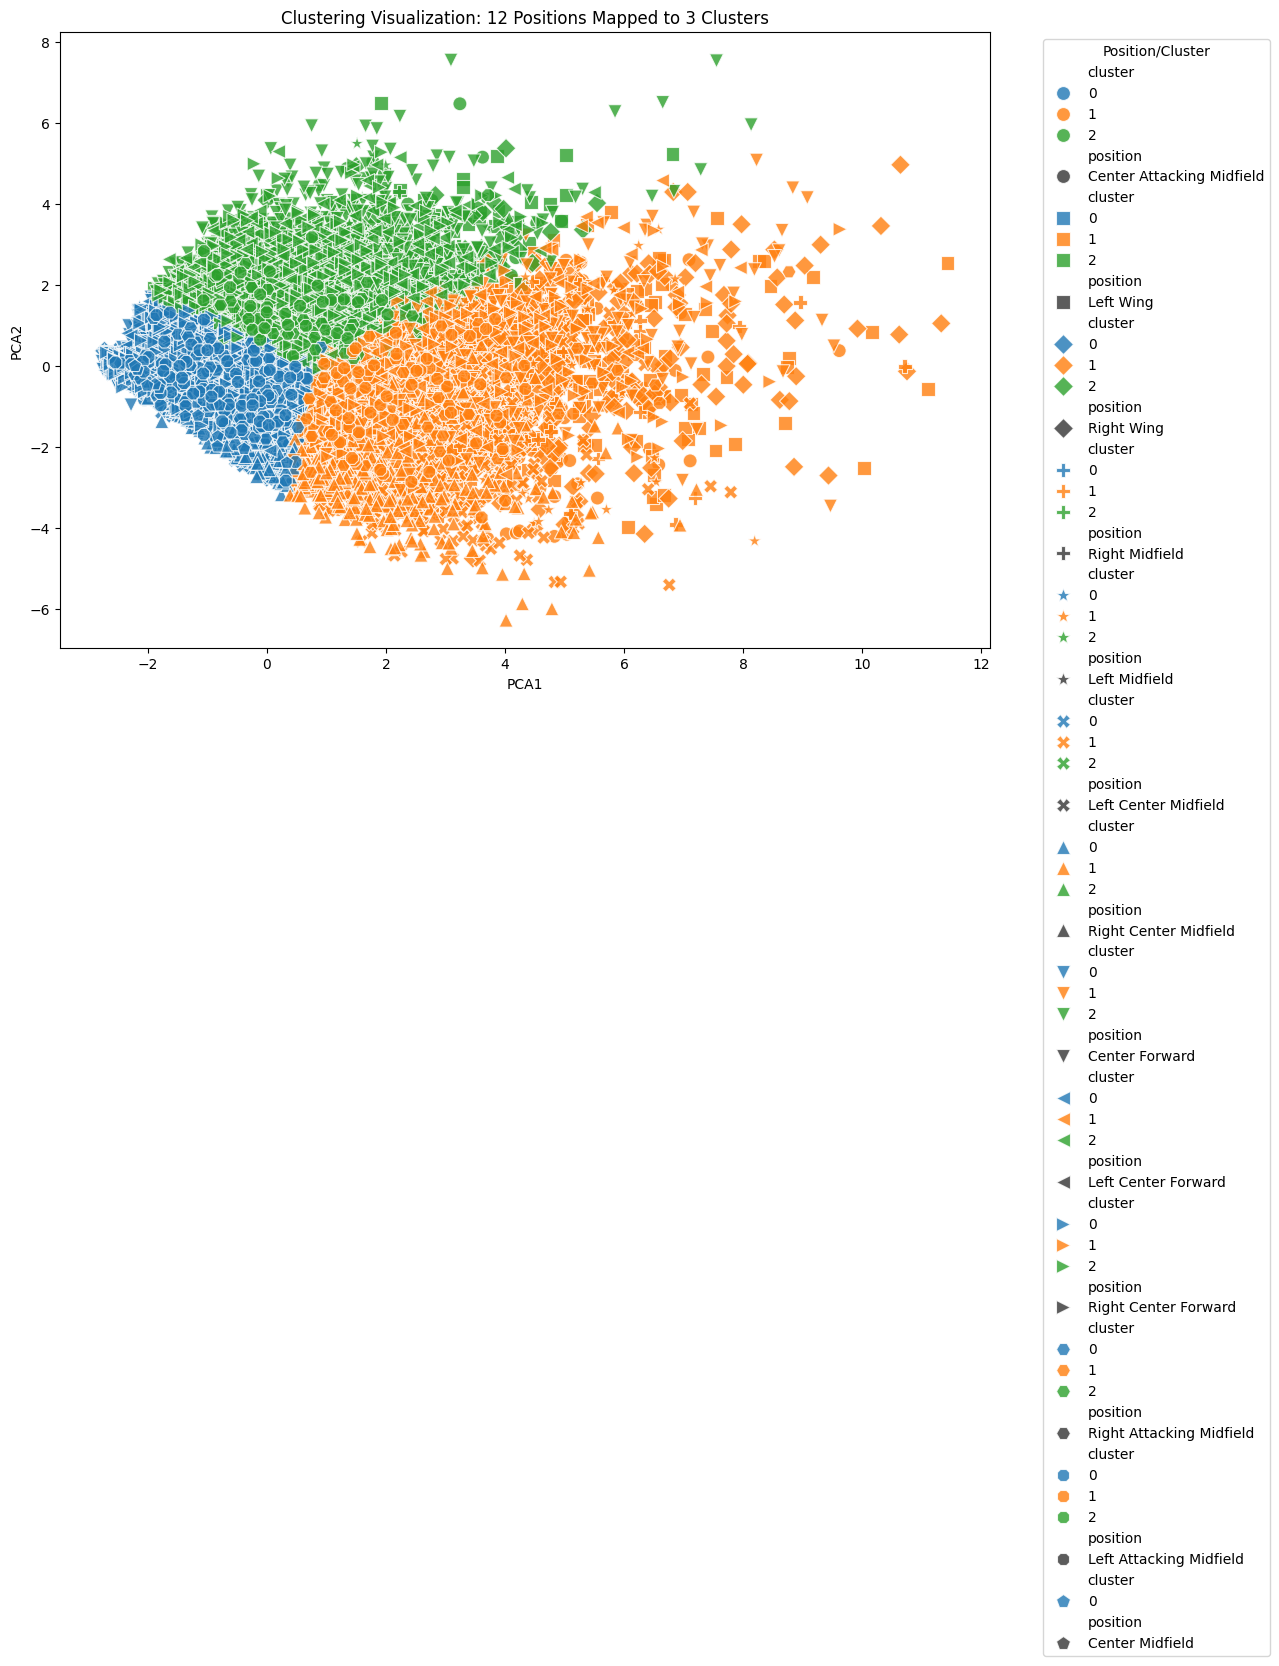

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# PCA dla redukcji do 2 wymiarów
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[stats])
df_scaled['PCA1'] = pca_result[:, 0]
df_scaled['PCA2'] = pca_result[:, 1]

# Unikalne pozycje i przypisanie markerów
positions = data11['position'].unique()[:-1]
markers = ['o', 's', 'D', 'P', '*', 'X', '^', 'v', '<', '>', 'H', '8', 'p'] # Dostosuj liczbę markerów
marker_map = dict(zip(positions, markers))

# Rysowanie wykresu
plt.figure(figsize=(12, 8))
for pos in positions:
    subset = df_scaled[df_scaled['position'] == pos]
    sns.scatterplot(
        x='PCA1', y='PCA2', data=subset,
        hue='cluster',  # Kolory dla klastrów
        palette='tab10',
        style='position',  # Markery dla pozycji
        markers=marker_map,
        s=100, alpha=0.8
    )

plt.title('Clustering Visualization: 12 Positions Mapped to 3 Clusters')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Position/Cluster')
plt.show()

In [53]:
# Grupowanie po pozycjach i obliczenie średnich statystyk
position_stats = data11.groupby('position')[['PAxG', 'xGA', 'xT+', 'shots_on_target', 
                                         'prog_carries', 'prog_pass', 
                                         'carries_into_pen', 'driblle_complete', 
                                         'good_passes']].median().reset_index()


In [54]:
from sklearn.preprocessing import StandardScaler

# Skalowanie statystyk
scaler = StandardScaler()
position_stats_scaled = position_stats.copy()
position_stats_scaled.iloc[:, 1:] = scaler.fit_transform(position_stats.iloc[:, 1:])


In [55]:
from sklearn.cluster import KMeans

# Klasteryzacja na 3 grupy
kmeans = KMeans(n_clusters=3, random_state=42)
position_stats_scaled['cluster'] = kmeans.fit_predict(position_stats_scaled.iloc[:, 1:])

# Dodanie grup do oryginalnych danych
position_stats['cluster'] = position_stats_scaled['cluster']


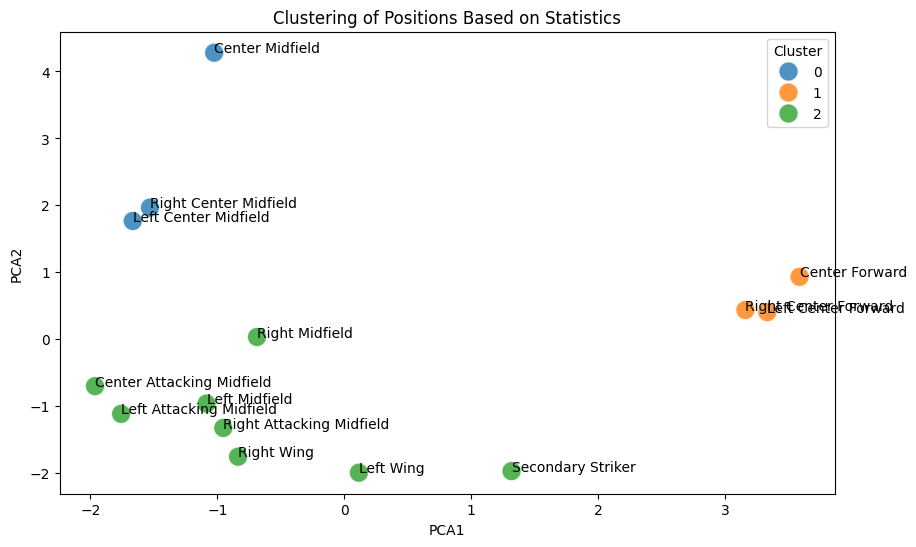

In [56]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# PCA na 2 wymiary
pca = PCA(n_components=2)
pca_result = pca.fit_transform(position_stats_scaled.iloc[:, 1:-1])  # Bez 'position' i 'cluster'
position_stats_scaled['PCA1'] = pca_result[:, 0]
position_stats_scaled['PCA2'] = pca_result[:, 1]

# Wykres
plt.figure(figsize=(10, 6))
sns.scatterplot(data=position_stats_scaled, x='PCA1', y='PCA2', hue='cluster', 
                palette='tab10', s=200, alpha=0.8)

# Dodanie etykiet pozycji
for i in range(position_stats_scaled.shape[0]):
    plt.text(position_stats_scaled['PCA1'].iloc[i], 
             position_stats_scaled['PCA2'].iloc[i], 
             position_stats_scaled['position'].iloc[i], fontsize=10)

plt.title('Clustering of Positions Based on Statistics')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()


In [57]:
print(position_stats[['position', 'cluster']])


                     position  cluster
0   Center Attacking Midfield        2
1              Center Forward        1
2             Center Midfield        0
3     Left Attacking Midfield        2
4         Left Center Forward        1
5        Left Center Midfield        0
6               Left Midfield        2
7                   Left Wing        2
8    Right Attacking Midfield        2
9        Right Center Forward        1
10      Right Center Midfield        0
11             Right Midfield        2
12                 Right Wing        2
13          Secondary Striker        2


Mamy rozdzielone, teraz sprawdźmy jak wpływa to na wyniki meczów oraz gole strzelone, stracone

In [58]:
data11['grouped_pos'] = data11['group'].map({0:'Midfield', 1:'Wing', 2:'Striker'})
data11.groupby('grouped_pos').size()

grouped_pos
Midfield    13586
Striker      5421
Wing         4650
dtype: int64

In [59]:
data_corr = data11.drop(columns=['player', 'position'])
# Tworzenie pivot_table (lub już masz te dane w dataframe)
data_corr2 = data_corr.pivot_table(
    index=['match_id', 'team'],
    columns='grouped_pos',
    values=list(data_corr.columns[2:15]),
    aggfunc='mean'  # MUSI BYĆ MEAN BO 1 TEAM MOŻE MIEĆ 10 NAPASTNIKÓW A DRUGI 1 I JAK TO PORÓWNAĆ
).reset_index().fillna(0)

# Spłaszczanie nagłówków, łącząc poziom wartości (np. PAxG, xGA) z poziomem pozycji
data_corr2.columns = ['_'.join(col).replace(' ', '_') if isinstance(col, tuple) else col for col in data_corr2.columns]

# Dodawanie kolumn różnicy (metric_grouped_pos_diff)
for col in data_corr2.columns[2:]:
    
    data_corr2[f"{col}_diff"] = data_corr2.groupby('match_id_')[col].transform(
        lambda x: x.diff().fillna(-x.diff().iloc[-1])
        )

# Wyświetlanie nowego DataFrame z kolumnami różnic
data_corr2.head()


,match_id_,team_,Events_Midfield,Events_Striker,Events_Wing,PAxG_Midfield,PAxG_Striker,PAxG_Wing,assist_Midfield,assist_Striker,...,prog_pass_Wing_diff,shots_on_target_Midfield_diff,shots_on_target_Striker_diff,shots_on_target_Wing_diff,xGA_Midfield_diff,xGA_Striker_diff,xGA_Wing_diff,xT+_Midfield_diff,xT+_Striker_diff,xT+_Wing_diff
0,7525,Russia,118.500000,102.0,179.0,0.126253,2.734158,1.549782,0.25,0.0,...,6.0,0.5,3.0,1.0,0.080058,-0.000000,0.406745,-0.003850,0.1790,0.713
1,7525,Saudi Arabia,160.200000,0.0,0.0,-0.022022,0.000000,0.000000,0.00,0.0,...,-6.0,-0.5,-3.0,-1.0,-0.080058,0.000000,-0.406745,0.003850,-0.1790,-0.713
2,7529,Croatia,161.750000,0.0,229.0,-0.100603,0.000000,-0.018098,0.00,0.0,...,1.0,-0.0,-0.0,-0.0,0.047556,-0.000000,-0.013396,0.100750,-0.0000,0.279
3,7529,Nigeria,136.500000,0.0,245.0,0.069778,0.000000,-0.028530,0.00,0.0,...,-1.0,0.0,0.0,0.0,-0.047556,0.000000,0.013396,-0.100750,0.0000,-0.279
4,7530,Australia,105.166667,0.0,0.0,0.217165,0.000000,0.000000,0.00,0.0,...,-0.0,-0.0,-1.5,-0.0,-0.016183,-0.214574,-0.000000,-0.133833,-0.1145,-0.000


In [60]:
matches_90 = []

for match in matches:
    if len(match['period'].unique())  == 2:
        matches_90.append(match['match_id'].iloc[0])
matches_90_df = pd.DataFrame({'match_id':matches_90})
matches_90_df

,match_id
0,3942852
1,3942785
2,3942416
3,3939986
4,3939973
...,...
2879,3888700
2880,3888699
2881,3888854
2882,3888705


In [61]:
matches_df = pd.concat(free_man_comps_sample_list, ignore_index=True)
matches_df2 = matches_df.merge(matches_90_df, on='match_id')
matches_df = matches_df[['match_id', 'match_date', 'competition', 'season', 'home_team', 'away_team', 'home_score', 'away_score']]

In [62]:
df = matches_df

# Funkcja do określenia wyniku zespołu
def determine_result(home_score, away_score, is_home):
    if home_score > away_score:
        return "Win" if is_home else "Lose"
    elif home_score < away_score:
        return "Lose" if is_home else "Win"
    else:
        return "Draw"

# Przekształcanie DataFrame z dodatkowymi kolumnami
rows = []
for _, row in df.iterrows():
    rows.append(
        {
            "match_id": row["match_id"],
            "match_date": row["match_date"],
            "team": row["home_team"],
            "team_result": determine_result(row["home_score"], row["away_score"], True),
            "goals_scored": row["home_score"],
            "goals_conceded": row["away_score"],
        }
    )
    rows.append(
        {
            "match_id": row["match_id"],
            "match_date": row["match_date"],
            "team": row["away_team"],
            "team_result": determine_result(row["home_score"], row["away_score"], False),
            "goals_scored": row["away_score"],
            "goals_conceded": row["home_score"],
        }
    )

# Tworzenie finalnego DataFrame
final_df = pd.DataFrame(rows)

final_df

,match_id,match_date,team,team_result,goals_scored,goals_conceded
0,3943077,2024-07-15,Argentina,Win,1,0
1,3943077,2024-07-15,Colombia,Lose,0,1
2,3943076,2024-07-14,Canada,Draw,2,2
3,3943076,2024-07-14,Uruguay,Draw,2,2
4,3942852,2024-07-11,Uruguay,Lose,0,1
...,...,...,...,...,...,...
5843,3888854,1962-05-30,Mexico,Lose,0,2
5844,3888705,1958-06-29,Brazil,Win,5,2
5845,3888705,1958-06-29,Sweden,Lose,2,5
5846,3888704,1958-06-24,Brazil,Win,5,2


In [63]:
data_corr3 = data_corr2.merge(final_df, left_on=['match_id_', 'team_'], right_on=['match_id', 'team'], how='left')

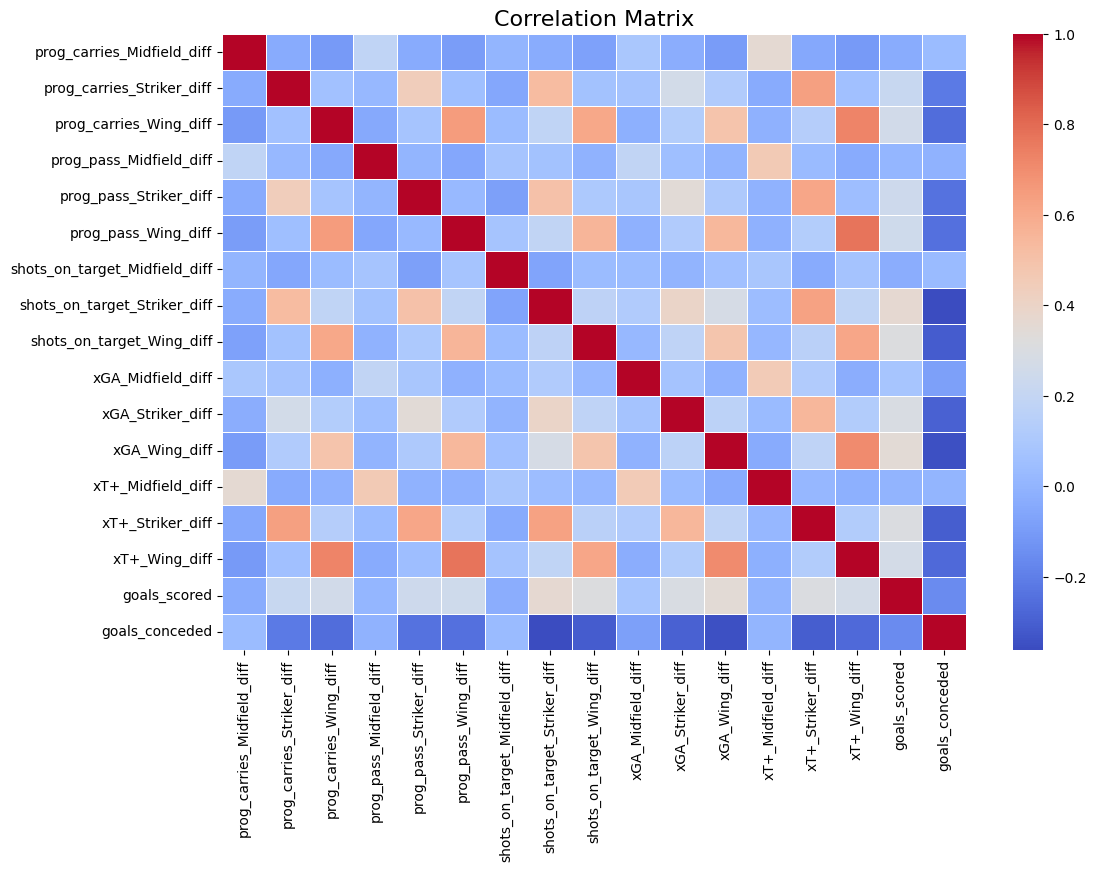

In [64]:
data_corr3 = data_corr3.drop(columns=['team', 'team_result', 'match_id','match_date'])

# Obliczenie korelacji
corr_matrix = data_corr3[list(data_corr3.columns[65:])].corr()

# Tworzenie wykresu ciepłoty
plt.figure(figsize=(12, 8))  # Możesz dostosować rozmiar wykresu
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Dodanie tytułu
plt.title('Correlation Matrix', fontsize=16)

# Wyświetlanie wykresu
plt.show()

Niestety statystyki pomocników nie mają istotnej korelacji z wynikiem, więc zostawiamy. Badamy skrzydłowych, pomocników ofensywnych oraz napastników.

Należy zbadać wpływ każdej z pozycji na wynik, wtedy będziemy mieć jasność.
A także wpływ danych czynników na wynik. (zrobione, ale oficjalnie).
Żeby wyszło, że paxg, xga, xT mają największy wpływ na wynik, a następnie że największy wpływ na wynik biorąc pod uwagę te statystyki mają Napastnicy i Skrzydłowi, Pomocnicy Ofensywni.

Chcę także na podstawie wag, które zostaną ustalone do modelu, zobaczyć jak pokrywa się to z miejscem w tabeli.
- za pomocą moich statystyk z wagami ustalić miejsce drużyny w tabeli
- sprawdzić jak to zrobi jakiś random forest (jakie wagi sam ustali) itd i porównać

Kiedy będę miał już model oceniający to mogę dopasować średnią wag i przedziały i porównać np. z sofą/flashsocrem np. biorąc pod uwagę cały turniej wc22 (będzie około 100 ocen), a następnie za pomocą random foresta jakiegoś zobaczyć jakie oni wagi dają do statystyk (moich).

W takim razie zobaczmy jaki wpływ dana statystyka ma na wynik, weźmy wszystkie statystyki. Także te defensywne. Stwórzmy także statystyki:
- forward_passes (w metrach ile jest bliżej bramki)

In [67]:
# Filtrowanie tylko raz dla odpowiednich wierszy

for match in matches:
    pass_mask = (match['type'] == "Pass") & (match['pass_outcome'].isna())
# Obliczanie różnicy dla przefiltrowanych wierszy
    match.loc[pass_mask, 'forward_pass'] = match.loc[pass_mask, 'pass_end_x'] - match.loc[pass_mask, 'x']

# Tworzenie nowej kolumny z warunkiem
    match['forward_pass+'] = match['forward_pass'].clip(lower=0)


Mamy utworzone. W takim razie zajmijmy się metrykami i ich wpływem na wynik meczu.
Stwórzmy dataframe, w którym będzie:
- match_id
- team
- position
- numeric_result
- goal_scored
- goal_conceded
- statystyki

Sprawdzimy, co ma jaką korelację itd...
Następnie zobaczymy 

np. xGA = 0.72 - duża korelacja
jak zobaczyć jakie pozycje uczestniczą w tej korelacji najbardziej?

Zobaczmy więc co ma wpływ na wyniki meczów (wszystkie statystyki)
Pamiętając o standaryzacji
Struktura:
match_id team paxg_diff result_numeric
Może faktycznie lepiej procentowe różnice niż liczbowe?
Sprawdźmy na przykładzie (paxg i passes)

In [68]:
players5 = players4
data1 = players5.merge(paxg_df, on=['match_id', 'player', 'team', 'position'], how='left').fillna(0)
data2 = data1.merge(xga_df, on=['match_id', 'player', 'team', 'position'], how='left').fillna(0)
data3 = data2.merge(xT_plus, on=['match_id', 'player'], how='left')
data4 = data3.merge(target_df, on=['match_id', 'player'], how='left').fillna(0)
data5 = data4.merge(progressive_carries_df, on=['match_id', 'player'], how='left').fillna(0)
data6 = data5.merge(progressive_passes_df, on=['match_id', 'player'], how='left').fillna(0)
data7 = data6.merge(carries_into_pen_df, on=['match_id', 'player'], how='left').fillna(0)
data8 = data7.merge(dribble_complete_df, on=['match_id', 'player'], how='left').fillna(0)
data9 = data8.merge(good_passes_df2, on=['match_id', 'player'], how='left').fillna(0)

In [69]:
# Kolumny ze statystykami
stats = ['PAxG', 'xGA', 'xT+', 'shots_on_target', 'prog_carries',
         'prog_pass', 'carries_into_pen', 'driblle_complete', 'good_passes']

# Normalizacja
scaler = StandardScaler()
df_scaled = data9.copy()
df_scaled[stats] = scaler.fit_transform(data9[stats])

# Grupowanie po pozycjach i obliczenie średnich statystyk
position_stats = data9.groupby('position')[['PAxG', 'xGA', 'xT+', 'shots_on_target', 
                                         'prog_carries', 'prog_pass', 
                                         'carries_into_pen', 'driblle_complete', 
                                         'good_passes']].median().reset_index()

# Skalowanie statystyk
scaler = StandardScaler()
position_stats_scaled = position_stats.copy()
position_stats_scaled.iloc[:, 1:] = scaler.fit_transform(position_stats.iloc[:, 1:])

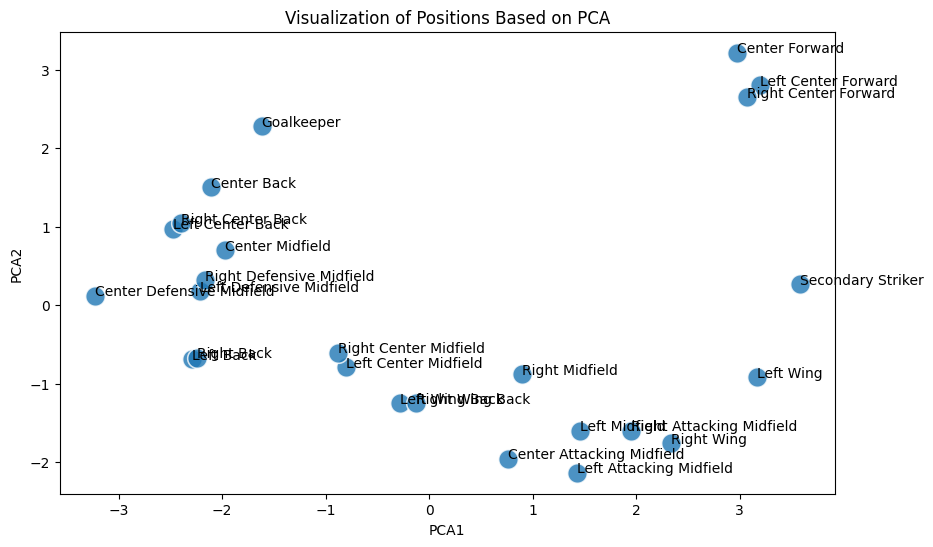

In [70]:
# PCA na 2 wymiary (bez klasteryzacji)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(position_stats_scaled.iloc[:, 1:])  # Bez 'position'
position_stats_scaled['PCA1'] = pca_result[:, 0]
position_stats_scaled['PCA2'] = pca_result[:, 1]

# Wykres bez klastrów
plt.figure(figsize=(10, 6))
sns.scatterplot(data=position_stats_scaled, x='PCA1', y='PCA2', 
                palette='tab10', s=200, alpha=0.8)

# Dodanie etykiet pozycji
for i in range(position_stats_scaled.shape[0]):
    plt.text(position_stats_scaled['PCA1'].iloc[i], 
             position_stats_scaled['PCA2'].iloc[i], 
             position_stats_scaled['position'].iloc[i], fontsize=10)

plt.title('Visualization of Positions Based on PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [71]:
pos_corr = position_stats_scaled.copy() 
pos_corr['value']= position_stats_scaled["PAxG"] + position_stats_scaled["xGA"] + position_stats_scaled["xT+"] + position_stats_scaled["shots_on_target"] + position_stats_scaled["prog_carries"] + position_stats_scaled["prog_pass"] + position_stats_scaled["carries_into_pen"] + position_stats_scaled["driblle_complete"] + position_stats_scaled["good_passes"]
pos_corr.sort_values(by='value')

,position,PAxG,xGA,xT+,shots_on_target,prog_carries,prog_pass,carries_into_pen,driblle_complete,good_passes,PCA1,PCA2,value
5,Goalkeeper,-0.432931,-1.027443,-2.154442,-0.5,-1.395037,-0.608781,-0.623610,-1.148733,-1.338376,-1.617404,2.282020,-9.229351
1,Center Back,-0.432931,-1.027443,-1.375160,-0.5,-1.395037,-0.608781,-0.623610,-1.148733,0.530212,-2.104641,1.506095,-6.581482
17,Right Center Back,-0.432931,-1.027443,-1.175809,-0.5,-1.395037,0.561951,-0.623610,-1.148733,0.413425,-2.394911,1.042226,-5.328185
8,Left Center Back,-0.432931,-1.027443,-1.139563,-0.5,-1.395037,0.561951,-0.623610,-1.148733,0.646999,-2.471713,0.975949,-5.058366
4,Center Midfield,-0.432931,-1.027443,-0.985519,-0.5,-0.369274,-0.608781,-0.623610,-1.148733,1.289326,-1.975351,0.698792,-4.406965
20,Right Defensive Midfield,-0.432931,-1.027443,-0.831475,-0.5,-0.369274,0.561951,-0.623610,-1.148733,0.880572,-2.169620,0.317770,-3.490942
11,Left Defensive Midfield,-0.432931,-1.027443,-0.650247,-0.5,-0.369274,0.561951,-0.623610,-1.148733,1.114145,-2.208740,0.178691,-3.076141
2,Center Defensive Midfield,-0.432931,-1.027443,-0.740861,-0.5,-1.395037,1.732684,-0.623610,-1.148733,1.931653,-3.227501,0.123515,-2.204278
16,Right Back,-0.432931,-1.027443,0.355570,-0.5,-0.369274,1.732684,-0.623610,-1.148733,0.880572,-2.246299,-0.666096,-1.133165
7,Left Back,-0.432931,-1.027443,0.346508,-0.5,-0.369274,1.732684,-0.623610,-1.148733,0.997359,-2.291765,-0.685585,-1.025440


In [72]:
position_share = position_stats.groupby('position')['PAxG'].sum()
position_share_percentage = (position_share / position_share.sum())
position_share_percentage

position
Center Attacking Midfield    0.000000
Center Back                  0.000000
Center Defensive Midfield    0.000000
Center Forward               0.260011
Center Midfield              0.000000
Goalkeeper                   0.000000
Left Attacking Midfield      0.000000
Left Back                    0.000000
Left Center Back             0.000000
Left Center Forward          0.239493
Left Center Midfield         0.000000
Left Defensive Midfield      0.000000
Left Midfield                0.000000
Left Wing                    0.000000
Left Wing Back               0.000000
Right Attacking Midfield     0.000000
Right Back                   0.000000
Right Center Back            0.000000
Right Center Forward         0.210226
Right Center Midfield        0.000000
Right Defensive Midfield     0.000000
Right Midfield               0.000000
Right Wing                   0.000000
Right Wing Back              0.000000
Secondary Striker            0.290269
Name: PAxG, dtype: float64

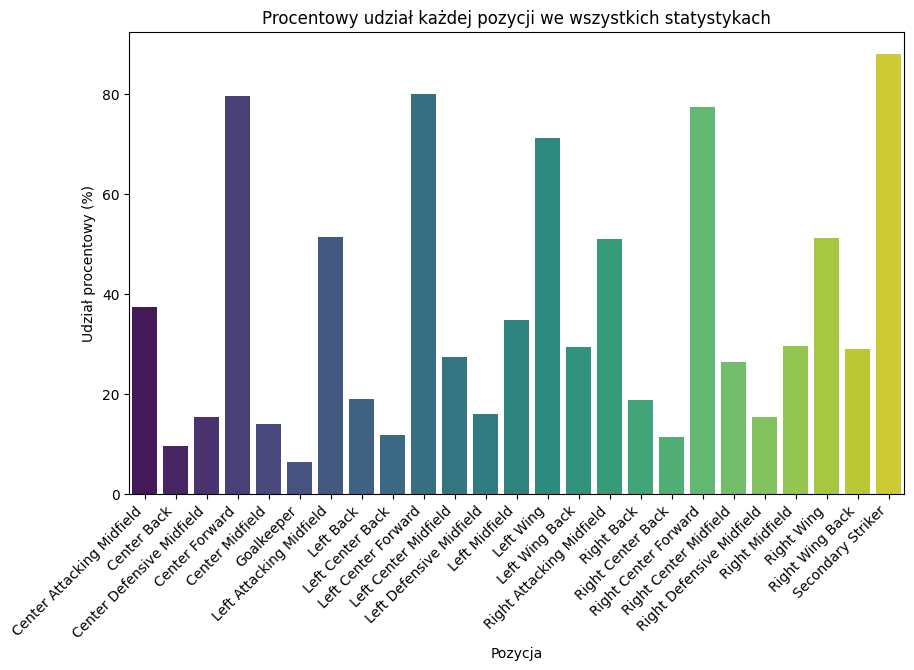

In [73]:
df = position_stats
for col in df.columns[1:]:  # Pomijamy kolumnę 'position'
    df[col + '_percentage'] = (df[col] / df[col].sum()) * 100

# Suma procentowych udziałów dla każdej pozycji
df['total_percentage'] = df.filter(like='_percentage').sum(axis=1)

# Wizualizacja
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='position', y='total_percentage', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Procentowy udział każdej pozycji we wszystkich statystykach')
plt.xlabel('Pozycja')
plt.ylabel('Udział procentowy (%)')
plt.show()

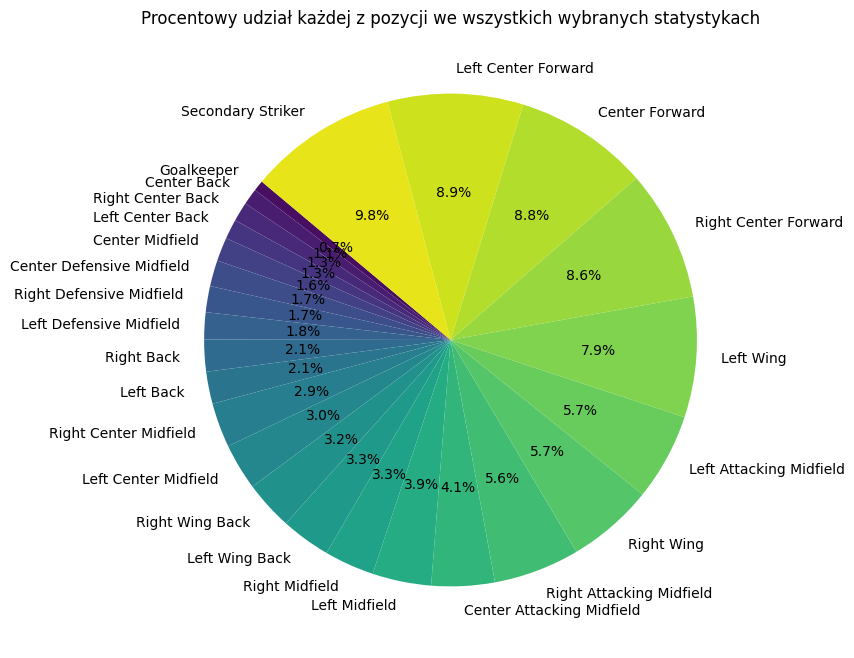

In [74]:
df['total_percentage%'] = (df['total_percentage'] / df['total_percentage'].sum()) * 100
df = df.sort_values(by='total_percentage%')
# Wykres kołowy dla ostatniej kolumny 'total_percentage'
plt.figure(figsize=(8, 8))
plt.pie(df['total_percentage%'], 
        labels=df['position'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('viridis', len(df)))
plt.title('Procentowy udział każdej z pozycji we wszystkich wybranych statystykach')
plt.show()


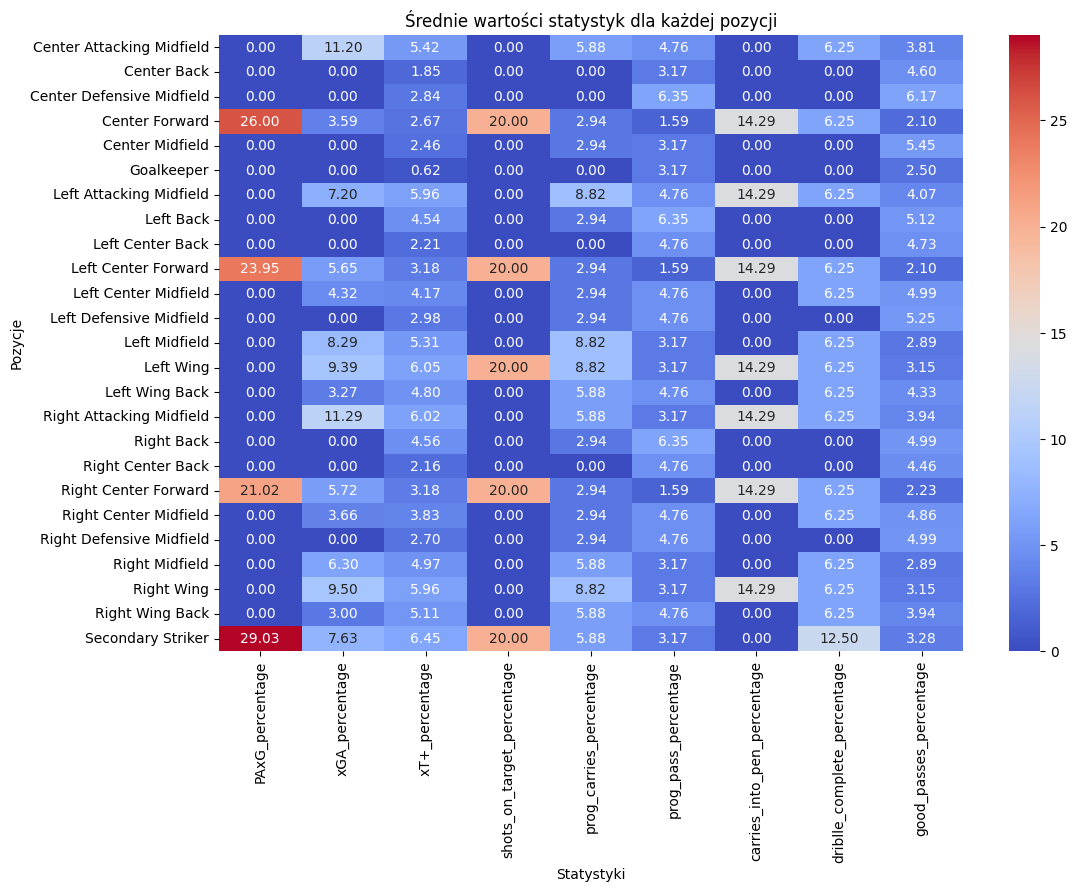

In [75]:
# Grupowanie po pozycji i obliczenie średnich wartości
position_means = df[list(list(df.columns[10:-2]) + ['position'])].groupby('position').mean()

# Wizualizacja: Heatmapa
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(position_means, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Średnie wartości statystyk dla każdej pozycji')
plt.xlabel('Statystyki')
plt.ylabel('Pozycje')
plt.show()

Po tej analizie weźmiemy zawodników o następujących pozycjach:

In [76]:
pos = ['Center Attacking Midfield',
     'Center Forward',
       'Center Midfield',
    'Left Attacking Midfield',
        'Left Center Forward',
        'Left Center Midfield',
       'Left Midfield', 
       'Left Wing',
       'Right Attacking Midfield',
         'Right Center Forward',
       'Right Center Midfield', 
       'Right Midfield', 
       'Right Wing', 
       'Secondary Striker'
       ]

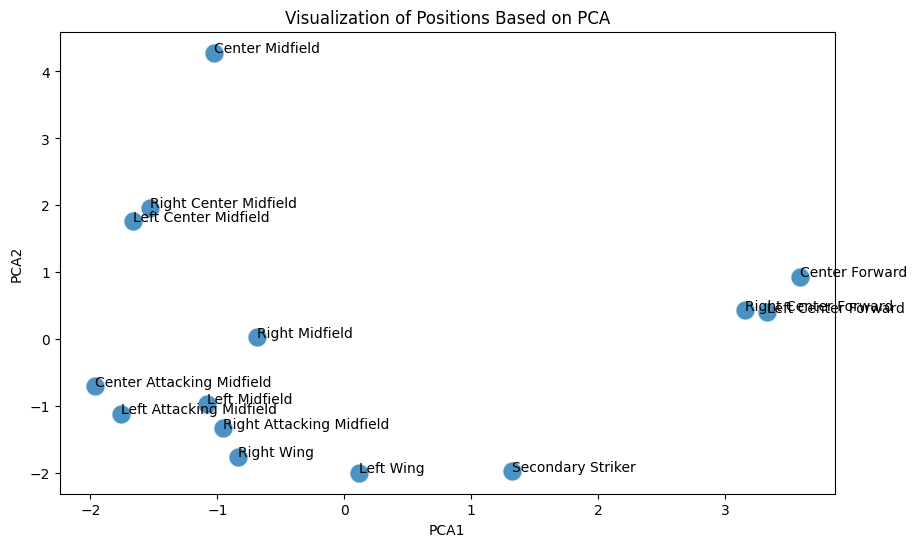

In [77]:
players6 = players5[players5['position'].isin(pos)]
data_pos = data9[data9['position'].isin(pos)]
# Grupowanie po pozycjach i obliczenie średnich statystyk
position_stats = data_pos.groupby('position')[['PAxG', 'xGA', 'xT+', 'shots_on_target', 
                                         'prog_carries', 'prog_pass', 
                                         'carries_into_pen', 'driblle_complete', 
                                         'good_passes']].median().reset_index()
# Skalowanie statystyk
scaler = StandardScaler()
position_stats_scaled = position_stats.copy()
position_stats_scaled.iloc[:, 1:] = scaler.fit_transform(position_stats.iloc[:, 1:])

# PCA na 2 wymiary (bez klasteryzacji)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(position_stats_scaled.iloc[:, 1:])  # Bez 'position'
position_stats_scaled['PCA1'] = pca_result[:, 0]
position_stats_scaled['PCA2'] = pca_result[:, 1]

# Wykres bez klastrów
plt.figure(figsize=(10, 6))
sns.scatterplot(data=position_stats_scaled, x='PCA1', y='PCA2', 
                palette='tab10', s=200, alpha=0.8)

# Dodanie etykiet pozycji
for i in range(position_stats_scaled.shape[0]):
    plt.text(position_stats_scaled['PCA1'].iloc[i], 
             position_stats_scaled['PCA2'].iloc[i], 
             position_stats_scaled['position'].iloc[i], fontsize=10)

plt.title('Visualization of Positions Based on PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

Usuwamy Right Center Midfield i Left i Right

In [78]:
pos = ['Center Attacking Midfield',
     'Center Forward',
    'Left Attacking Midfield',
        'Left Center Forward',
       'Left Midfield', 
       'Left Wing',
       'Right Attacking Midfield',
         'Right Center Forward',
       'Right Midfield', 
       'Right Wing', 
       'Secondary Striker'
       ]

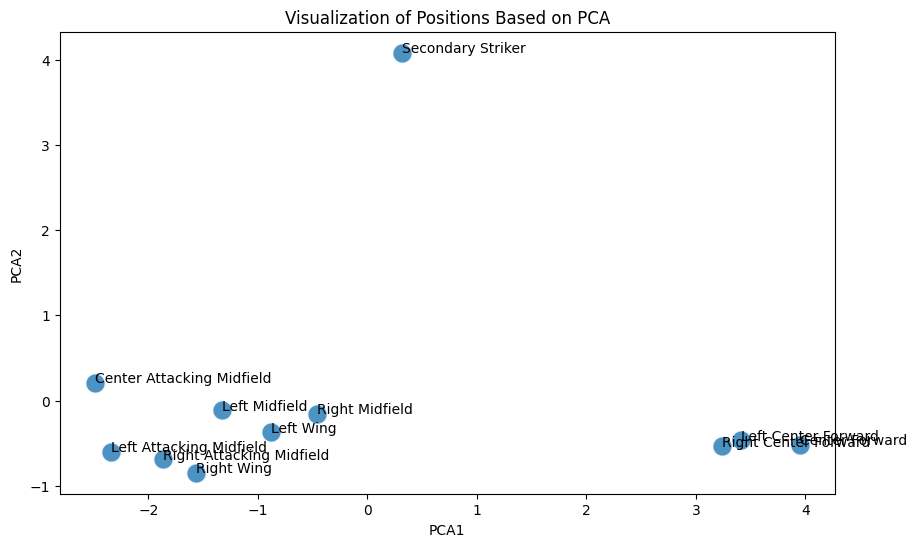

In [79]:
data_pos = data9[data9['position'].isin(pos)]
# Grupowanie po pozycjach i obliczenie średnich statystyk
position_stats = data_pos.groupby('position')[['PAxG', 'xGA', 'xT+', 'shots_on_target', 
                                         'prog_carries', 'prog_pass', 
                                         'carries_into_pen', 'driblle_complete', 
                                         'good_passes']].median().reset_index()
scaler = StandardScaler()
position_stats_scaled = position_stats.copy()
position_stats_scaled.iloc[:, 1:] = scaler.fit_transform(position_stats.iloc[:, 1:])

# PCA na 2 wymiary (bez klasteryzacji)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(position_stats_scaled.iloc[:, 1:])  # Bez 'position'
position_stats_scaled['PCA1'] = pca_result[:, 0]
position_stats_scaled['PCA2'] = pca_result[:, 1]

# Wykres bez klastrów
plt.figure(figsize=(10, 6))
sns.scatterplot(data=position_stats_scaled, x='PCA1', y='PCA2', 
                palette='tab10', s=200, alpha=0.8)

# Dodanie etykiet pozycji
for i in range(position_stats_scaled.shape[0]):
    plt.text(position_stats_scaled['PCA1'].iloc[i], 
             position_stats_scaled['PCA2'].iloc[i], 
             position_stats_scaled['position'].iloc[i], fontsize=10)

plt.title('Visualization of Positions Based on PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()


In [80]:
pos_strikers = ['Center Forward',
 'Left Center Forward',
 'Right Center Forward',
 'Secondary Striker']

pos_wings = ['Center Attacking Midfield',
 
 'Left Attacking Midfield',

 'Left Midfield',
 'Left Wing',
 'Right Attacking Midfield',
 
 'Right Midfield',
 'Right Wing',
 ]
data_pos.groupby('position').size()

position
Center Attacking Midfield    2197
Center Forward               3839
Left Attacking Midfield       167
Left Center Forward          1566
Left Midfield                1475
Left Wing                    2956
Right Attacking Midfield      159
Right Center Forward         1563
Right Midfield               1489
Right Wing                   2880
Secondary Striker               7
dtype: int64

In [81]:
def assign_pos(position):
    if position in pos_strikers:
        return 'Striker'
    else:
        return 'Midfield'
    
data = data_pos.copy()
data['grouped_position'] = data['position'].apply(assign_pos)
data.groupby('grouped_position').size()

grouped_position
Midfield    11323
Striker      6975
dtype: int64

In [82]:
data_full1 = data.groupby(['match_id', 'team'])[data.columns[5:-1]].sum().reset_index()

In [85]:
final_df.head()

,match_id,match_date,team,team_result,goals_scored,goals_conceded
0,3943077,2024-07-15,Argentina,Win,1,0
1,3943077,2024-07-15,Colombia,Lose,0,1
2,3943076,2024-07-14,Canada,Draw,2,2
3,3943076,2024-07-14,Uruguay,Draw,2,2
4,3942852,2024-07-11,Uruguay,Lose,0,1


In [86]:
final_df['result_numeric'] = final_df['team_result'].map({'Win':1, 'Lose':-1, 'Draw':0})
final_df.head()

,match_id,match_date,team,team_result,goals_scored,goals_conceded,result_numeric
0,3943077,2024-07-15,Argentina,Win,1,0,1
1,3943077,2024-07-15,Colombia,Lose,0,1,-1
2,3943076,2024-07-14,Canada,Draw,2,2,0
3,3943076,2024-07-14,Uruguay,Draw,2,2,0
4,3942852,2024-07-11,Uruguay,Lose,0,1,-1


In [87]:
data_full1 = data.groupby(['match_id', 'team'])[data.columns[5:-1]].sum().reset_index()

In [88]:
data_full2 = data_full1.merge(final_df[['match_id', 'team', 'result_numeric']], on=['match_id', 'team'], how='left')

In [89]:
for col in data_full2.columns[5:-1]:
    data_full2[f"{col}_diff"] = data_full2.groupby('match_id')[col].transform(
        lambda x: (
        (x.diff() / x.max()).fillna(-x.diff().iloc[-1] / x.max()) * 100
        if x.max() != 0 else 0
    )
    )
data_full2 = data_full2.dropna()
df_scaled = data_full2.copy()

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Dane wejściowe i wynikowe
X = df_scaled[df_scaled.columns[15:]]  # Wybierz kolumny statystyk
y = df_scaled['result_numeric']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

# Regresja logistyczna
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Wyniki
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Wagi cech
coefficients = model.coef_
feature_importance = pd.DataFrame(coefficients, columns=X.columns, index=model.classes_)
print(feature_importance)


              precision    recall  f1-score   support

          -1       0.61      0.82      0.70       437
           0       0.00      0.00      0.00       276
           1       0.63      0.80      0.71       456

    accuracy                           0.62      1169
   macro avg       0.41      0.54      0.47      1169
weighted avg       0.47      0.62      0.54      1169

    PAxG_diff  xGA_diff  xT+_diff  shots_on_target_diff  prog_carries_diff  \
-1  -0.000681 -0.004744  0.002480             -0.007431          -0.003549   
 0  -0.000206  0.000042 -0.000051              0.000187           0.000161   
 1   0.000887  0.004703 -0.002429              0.007243           0.003388   

    prog_pass_diff  carries_into_pen_diff  driblle_complete_diff  \
-1       -0.000521              -0.002410              -0.001402   
 0        0.000258              -0.000214               0.000085   
 1        0.000262               0.002624               0.001317   

    good_passes_diff  
-1        

In [99]:
from sklearn.ensemble import RandomForestClassifier

# Dopasowanie modelu
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

# Znaczenie cech
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                 Feature  Importance
0              PAxG_diff    0.231790
1               xGA_diff    0.127853
2               xT+_diff    0.105383
4      prog_carries_diff    0.099177
3   shots_on_target_diff    0.097950
8       good_passes_diff    0.096873
5         prog_pass_diff    0.083894
7  driblle_complete_diff    0.078563
6  carries_into_pen_diff    0.078516


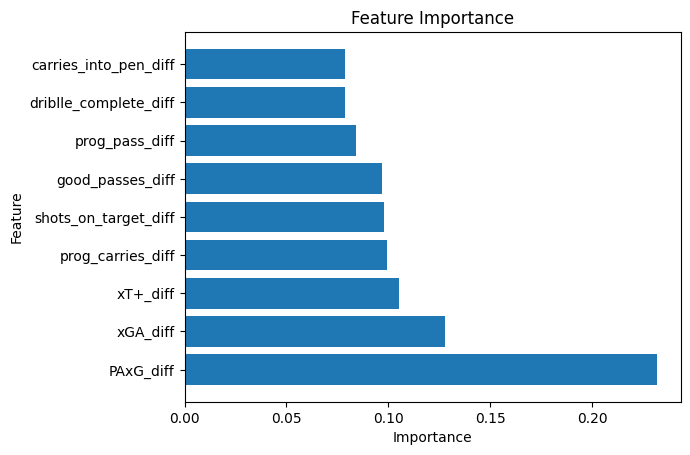

In [100]:
import matplotlib.pyplot as plt
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()


In [101]:
# przejęcia = inter + reco

inter_list = []

for match in matches:
    
    inter = match[(match['type'] == 'Interception') & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='interception')
    inter_list.append(inter)

inter_df = pd.concat(inter_list, ignore_index=True)

In [102]:
recovery_list = []

for match in matches:
    
    recov = match[(match['type'] == 'Ball Recovery') & (match['period'] < 3) ].groupby(['player', 'match_id']).size().reset_index(name='recovery')
    recovery_list.append(recov)

recovery_df = pd.concat(recovery_list, ignore_index=True)

In [103]:
clearance_list = []

for match in matches:
    clearance = match[(match['type'] == 'Clearance') & (match['period'] < 3) ].groupby(['player', 'match_id']).size().reset_index(name='clearance')
    clearance_list.append(clearance)

clearance_df = pd.concat(clearance_list, ignore_index=True)

In [104]:
error_list = []

for match in matches:
    
    error = match[(match['type'] == 'Error') & (match['period'] < 3) ].groupby(['player', 'match_id']).size().reset_index(name='error')
    error_list.append(error)

error_df = pd.concat(error_list, ignore_index=True)

In [105]:
dispossessed_list = []

for match in matches:
    
    dispossessed = match[(match['type'] == 'Dispossessed') & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='dispossessed')
    dispossessed_list.append(dispossessed)

dispossessed_df = pd.concat(dispossessed_list, ignore_index=True)

In [106]:
miscontrol_list = []

for match in matches:
    
    miscontrol = match[(match['type'] == 'Miscontrol') & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='miscontrol')
    miscontrol_list.append(miscontrol)

miscontrol_df = pd.concat(miscontrol_list, ignore_index=True)

In [107]:
bad_passes_list = []
for match in matches:
    bad_passes = match[(match["type"] == "Pass") & (match['period'] < 3) & (match["pass_outcome"].isin(["Incomplete", "Out"]))].groupby(['player', 'match_id']).size().reset_index(name="bad_passes").fillna(0)
    bad_passes_list.append(bad_passes)

bad_passes_df2 = pd.concat(bad_passes_list, ignore_index=True)

In [108]:
data10 = data9.merge(dribble_failed_df, on=['match_id', 'player'], how='left').fillna(0)
data11 = data10.merge(bad_passes_df2, on=['match_id', 'player'], how='left').fillna(0)
data12 = data11.merge(inter_df[inter_df.columns[:3]], on=['match_id', 'player'], how='left').fillna(0)
data13 = data12.merge(recovery_df[recovery_df.columns[:3]], on=['match_id', 'player'], how='left').fillna(0)
data14= data13.merge(clearance_df[clearance_df.columns[:3]], on=['match_id', 'player'], how='left').fillna(0)
data15= data14.merge(error_df[error_df.columns[:3]], on=['match_id', 'player'], how='left').fillna(0)
data16= data15.merge(dispossessed_df[dispossessed_df.columns[:3]], on=['match_id', 'player'], how='left').fillna(0)
data17= data16.merge(miscontrol_df[miscontrol_df.columns[:3]], on=['match_id', 'player'], how='left').fillna(0)

In [109]:
metric= 'shots'

metric_list = []

for match in matches:
    metric_df = (
    match[(match['type'] == 'Shot') & (match['shot_type'] != 'Penalty') & (match['period'] < 3)]
    .groupby(['match_id', 'player'])
    .size()
    .reset_index(name=metric)
)
    metric_list.append(metric_df)
shots = pd.concat(metric_list, ignore_index=True)

In [110]:
data18= data17.merge(shots, on=['match_id', 'player'], how='left').fillna(0)


In [111]:
metric= 'npxg'

metric_list = []

for match in matches:
    metric_df = (
    match[(match['type'] == 'Shot') & (match['shot_type'] != 'Penalty') & (match['period'] < 3)]
    .groupby(['match_id', 'player'])['shot_statsbomb_xg']
    .sum()
    .reset_index(name=metric)
)
    metric_list.append(metric_df)
npxg_df = pd.concat(metric_list, ignore_index=True)

In [112]:
data19= data18.merge(npxg_df, on=['match_id', 'player'], how='left').fillna(0)


In [113]:
tackle_list = []
for match in matches:
    
    tackle = match[(match['type'] == 'Duel') & (match['duel_outcome'].isin(["Won", "Lost Out", "Success", "Success In Play", "Success Out"])) & (match['period'] < 3)].groupby(['match_id', 'player']).size().reset_index(name='tackle')
    tackle_list.append(tackle)

tackle_df = pd.concat(tackle_list, ignore_index=True)

In [114]:
data20= data19.merge(tackle_df, on=['match_id', 'player'], how='left').fillna(0)
metric= 'xT'

metric_list = []

for match in matches:
    metric_df = (
    match[(match['period'] < 3)]
    .groupby(['match_id', 'player'])['xT']
    .sum()
    .reset_index(name=metric)
)
    metric_list.append(metric_df)
xT_df = pd.concat(metric_list, ignore_index=True)

In [115]:
data21= data20.merge(xT_df, on=['match_id', 'player'], how='left').fillna(0)
metric= 'fwp'

metric_list = []

for match in matches:
    metric_df = (
    match[(match['period'] < 3)]
    .groupby(['match_id', 'player'])['forward_pass']
    .sum()
    .reset_index(name=metric)
)
    metric_list.append(metric_df)
fwp_df = pd.concat(metric_list, ignore_index=True)

In [116]:
data22= data21.merge(fwp_df, on=['match_id', 'player'], how='left').fillna(0)
metric= 'fwp+'

metric_list = []

for match in matches:
    metric_df = (
    match[(match['period'] < 3)]
    .groupby(['match_id', 'player'])['forward_pass+']
    .sum()
    .reset_index(name=metric)
)
    metric_list.append(metric_df)
fwp_plus_df = pd.concat(metric_list, ignore_index=True)

In [117]:
# duels

win = ['Won', 'Success', 'Success In Play']
lost = ['Lost In Play', 'Lost Out']

In [118]:
duels_won_list = []
for match in matches:
    
    duels_won = match[(match['duel_outcome'].isin(win)) & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='duels_won')
    duels_won_list.append(duels_won)

duels_won_df = pd.concat(duels_won_list, ignore_index=True)

In [119]:
# 50/50
for match in matches[1:]:
    if '50_50' in match.columns:
        match['50_50_outcome'] = match['50_50'].apply(lambda x: x['outcome']['name'] if isinstance(x,dict) and 'outcome' in x and 'name' in x['outcome'] else np.nan)


In [120]:
duels_50_won_list = []

for match in matches:
    if '50_50_outcome' in match.columns:
        duels_50_won = match[(match['50_50_outcome'].isin(win)) & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='duels_50_won')
        duels_50_won_list.append(duels_50_won)

duels_50_won_df = pd.concat(duels_50_won_list, ignore_index=True)

In [121]:
duels_lost_list = []
for match in matches:
    
    duels_lost = match[(match['duel_outcome'].isin(lost)) & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='duels_lost')
    duels_lost_list.append(duels_lost)

duels_lost_df = pd.concat(duels_lost_list, ignore_index=True)

In [122]:
duels_50_lost_list = []
for match in matches:
    if '50_50_outcome' in match.columns:
        duels_50_lost = match[(match['50_50_outcome'].isin(lost)) & (match['period'] < 3) ].groupby(['player', 'match_id']).size().reset_index(name='duels_50_lost')
        duels_50_lost_list.append(duels_50_lost)

duels_50_lost_df = pd.concat(duels_50_lost_list, ignore_index=True)

In [123]:
# przegrane pojedynki powietrzne

aerial_lost_list = []
for match in matches:
    
    aerial_lost = match[(match['duel_type'] == 'Aerial Lost') & (match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='aerial_lost')
    aerial_lost_list.append(aerial_lost)

aerial_lost_df = pd.concat(aerial_lost_list, ignore_index=True)

In [124]:
data23= data22.merge(fwp_plus_df, on=['match_id', 'player'], how='left').fillna(0)
data24= data23.merge(duels_won_df, on=['match_id', 'player'], how='left').fillna(0)
data25 = data24.merge(duels_50_won_df, on=['match_id', 'player'], how='left').fillna(0)
data26 = data25.merge(duels_lost_df, on=['match_id', 'player'], how='left').fillna(0)
data27 = data26.merge(duels_50_lost_df, on=['match_id', 'player'], how='left').fillna(0)
data28 = data27.merge(aerial_lost_df, on=['match_id', 'player'], how='left').fillna(0)


In [125]:
aerial_wons_count_list = []

for at in matches:
    # Filtrujemy tylko "Aerial Lost" i wybieramy potrzebne kolumny
    a1 = at[at['duel_type'] == "Aerial Lost"][['match_id', 'duel_type', 'duel_outcome', 'minute', 'second', 'player', 'team', 'related_events']]
    a2 = at[['match_id', "player", 'team', "type", "id"]]
    
    # Upewniamy się, że 'related_events' jest listą (lub zamieniamy NaN na pustą listę)
    a1['related_events'] = a1['related_events'].apply(lambda x: x if isinstance(x, list) else [])
    
    # Rozpakowujemy listy w 'related_events' na osobne wiersze
    a1_exploded = a1.explode('related_events').reset_index(drop=True)
    
    # Łączymy 'a1_exploded' z 'a2' na podstawie 'related_events' i 'id'
    aerial_wonsx = a1_exploded.merge(a2, left_on='related_events', right_on='id')[
        ['match_id_y', 'player_y', 'team_y']
    ].groupby(['match_id_y', 'player_y', 'team_y']).size().reset_index(name='aerial_lost_count')
    
    # Zmieniamy nazwy kolumn
    aerial_wonsx.columns = ['match_id', 'player', 'team', 'aerial_lost_count']
    
    # Dodajemy wynik do listy
    aerial_wons_count_list.append(aerial_wonsx)

# Łączymy wyniki z wszystkich iteracji w jeden DataFrame
aerial_wons_count_df = pd.concat(aerial_wons_count_list, ignore_index=True)

# Wyświetlamy wynik
aerial_wons_count_df


,match_id,player,team,aerial_lost_count
0,3943077,Alexis Mac Allister,Argentina,2
1,3943077,Carlos Eccehomo Cuesta Figueroa,Colombia,4
2,3943077,Cristian Gabriel Romero,Argentina,4
3,3943077,Davinson Sánchez Mina,Colombia,4
4,3943077,Enzo Fernandez,Argentina,1
...,...,...,...,...
44910,3888704,Raymond Kaelbel,France,1
44911,3888704,Robert Jonquet,France,5
44912,3888704,Roger Piantoni,France,1
44913,3888704,Waldyr Pereira,Brazil,1


In [126]:
aerial_won_shot_list = []

for match in matches:
    if 'shot_aerial_won' in match.columns:
        aerial_won_shot = match[~(match['shot_aerial_won'].isna()) & (match['period'] < 3)].groupby(['match_id', 'player']).size().reset_index(name='aerial_won_shot')
        aerial_won_shot_list.append(aerial_won_shot)

aerial_won_shot_df = pd.concat(aerial_won_shot_list, ignore_index=True)

In [127]:
# przegrane poj pow
miscontrol_aerial_won_list = []

for match in matches:
    if 'miscontrol_aerial_won' in match.columns:
        miscontrol_ar_w = match[(match['type'] == 'Miscontrol') & (~match['miscontrol_aerial_won'].isna()) &(match['period'] < 3)].groupby(['player', 'match_id']).size().reset_index(name='miscontrol_aerial_won')
        miscontrol_aerial_won_list.append(miscontrol_ar_w)

miscontrol_ar_w_df = pd.concat(miscontrol_aerial_won_list, ignore_index=True)

In [128]:
data29 = data28.merge(aerial_won_shot_df, on=['match_id', 'player'], how='left').fillna(0)
data30 = data29.merge(miscontrol_ar_w_df, on=['match_id', 'player'], how='left').fillna(0)
aerial_wons_count_df.columns = ['match_id', 'player', 'team', 'aerial_wons_count']
data31 = data30.merge(aerial_wons_count_df[['match_id', 'player', 'aerial_wons_count']], on=['match_id', 'player'], how='left').fillna(0)
data_model = data31.copy()
data_model['passes'] = data_model['good_passes'] + data_model['bad_passes']
data_model['dribbles'] = data_model['driblle_complete'] + data_model['driblle_failed']
data_model['basic_duels_won'] = data_model['duels_50_won'] + data_model['duels_won']
data_model['basic_duels_lost'] = data_model['duels_50_lost'] + data_model['duels_lost']
data_model['basic_duels'] = data_model['basic_duels_lost'] + data_model['basic_duels_won']
data_model['won_aerial_all'] = data_model['aerial_wons_count'] + data_model['aerial_won_shot']
data_model['lost_aerial_all'] = data_model['aerial_lost'] + data_model['miscontrol_aerial_won']
data_model['aerial'] = data_model['won_aerial_all'] + data_model['lost_aerial_all']
data_model['duels'] = data_model['aerial'] + data_model['basic_duels']
data_model['defensive_won'] = data_model['interception'] + data_model['recovery'] + data_model['clearance'] + data_model['tackle']
data_model['defensive_lost'] = data_model['miscontrol'] + data_model['error'] + data_model['dispossessed']

In [129]:
data_model_corr = data_model.copy()

In [130]:
def determine_result(group):
    # Pobierz gole obu zespołów
    goals = group['goals'].values
    # Porównaj gole
    if len(goals) == 2:  # Dla każdego meczu powinny być dwa wiersze
        if goals[0] > goals[1]:
            group['result'] = [1, -1]
        elif goals[0] < goals[1]:
            group['result'] = [-1, 1]
        else:
            group['result'] = [0, 0]
    return group

# Grupowanie po match_id i obliczanie kolumny result


In [131]:
data_model_corr2 = data_model_corr.groupby(['match_id', 'team'])[data_model_corr.columns[6:]].sum().reset_index()
data_model_corr2 = data_model_corr2.groupby('match_id').apply(determine_result).reset_index(drop=True)
c = data_model_corr2[data_model_corr2.columns[2:]].corr()
c[['result', 'goals']].sort_values(by='result', ascending=False)

,result,goals
result,1.000000,0.651518
goals,0.651518,1.000000
PAxG,0.561158,0.808932
assist,0.508396,0.766600
shots_on_target,0.463676,0.646372
npxg,0.437237,0.607434
xGA,0.410280,0.536458
carries_into_pen,0.339808,0.378606
shots,0.300869,0.363539
xT+,0.300147,0.340940


In [132]:
data_model_corr3 = data_model_corr2.drop(columns='duels_50_lost')
data_model_corr4 = pd.DataFrame()
for col in data_model_corr3.columns[4:-1]:
    data_model_corr3[f"{col}_diff"] = data_model_corr3.groupby('match_id')[col].transform(
        lambda x: x.diff().fillna(-x.diff().iloc[-1])
    )
c2 = data_model_corr3[list(data_model_corr3.columns[45:]) + ['goals', 'assist']].corr()
c2[['result', 'goals']].sort_values(by='result', ascending=False)


,result,goals
result,1.000000,0.651518
PAxG_diff,0.738348,0.633881
goals,0.651518,1.000000
shots_on_target_diff,0.600909,0.524653
npxg_diff,0.556881,0.505690
xGA_diff,0.526532,0.475208
assist,0.508396,0.766600
carries_into_pen_diff,0.439317,0.370532
shots_diff,0.371920,0.334765
prog_carries_diff,0.349605,0.307214


In [133]:
data_model_corr3['prog'] = data_model_corr3['prog_carries'] + data_model_corr3['prog_pass']

In [134]:
data_model_pos = data_model_corr[data_model_corr['position'].isin(pos)]

In [135]:
data_model_pos['prog'] = data_model_pos['prog_carries'] + data_model_pos['prog_pass']
data_model_pos2 = data_model_pos.groupby(['match_id', 'team'])[data_model_pos.columns[6:]].sum().reset_index()
data_model_pos3 = data_model_pos2.groupby('match_id').apply(determine_result).reset_index(drop=True)
data_model_pos3 = data_model_pos3.drop(columns='duels_50_lost')
c3 = data_model_pos3[data_model_pos3.columns[2:]].corr()
c3[['result', 'goals']].sort_values(by='result', ascending=False)

,result,goals
result,1.000000,0.650217
goals,0.650217,1.000000
PAxG,0.551596,0.818651
shots_on_target,0.458235,0.667561
npxg,0.445032,0.628279
assist,0.357900,0.528547
shots,0.344930,0.436397
xGA,0.323899,0.437372
carries_into_pen,0.303316,0.356628
prog,0.279980,0.319881


In [136]:
for col in data_model_pos3.columns[4:-1]:
    data_model_pos3[f"{col}_diff"] = data_model_pos3.groupby('match_id')[col].transform(
        lambda x: x.diff().fillna(-x.diff().iloc[-1])
    )
c4 = data_model_pos3[list(data_model_pos3.columns[45:]) + ['goals', 'assist']].corr()
c4[['result', 'goals']].sort_values(by='result', ascending=False)

,result,goals
result,1.000000,0.650217
PAxG_diff,0.743441,0.625340
goals,0.650217,1.000000
shots_on_target_diff,0.610134,0.520919
npxg_diff,0.583135,0.506579
shots_diff,0.445422,0.375750
xGA_diff,0.436791,0.389025
carries_into_pen_diff,0.402811,0.334810
prog_diff,0.381412,0.318917
prog_carries_diff,0.359943,0.295547


In [137]:
data_model_corr5 = data_model_corr3.drop(columns='prog')
data_model_corr5['prog_diff'] = data_model_corr5['prog_carries_diff'] + data_model_corr5['prog_pass_diff']
data_model_corr6 = data_model_corr5[data_model_corr5.columns[45:]]

In [140]:
import statsmodels.api as sm
scaler = StandardScaler()
data_model_corr6_scaled = data_model_corr6.copy()
data_model_corr6_scaled[data_model_corr6_scaled.columns[1:]] = scaler.fit_transform(data_model_corr6_scaled[data_model_corr6_scaled.columns[1:]])
X = data_model_corr6_scaled[data_model_corr6_scaled.columns[1:]]
X = sm.add_constant(X)  # Dodanie stałej (biasu) do modelu

# Zmienna zależna (rezultat meczu)
y = data_model_corr6_scaled["result"]

# Regresja liniowa
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 result   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     349.1
Date:                Mon, 05 May 2025   Prob (F-statistic):               0.00
Time:                        16:47:42   Log-Likelihood:                -4393.3
No. Observations:                5848   AIC:                             8849.
Df Residuals:                    5817   BIC:                             9055.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [143]:
from sklearn.ensemble import RandomForestClassifier

# Dopasowanie modelu
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

# Znaczenie cech
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                       Feature  Importance
1                    PAxG_diff    0.212145
19                   npxg_diff    0.079067
4         shots_on_target_diff    0.065607
2                     xGA_diff    0.055386
14              clearance_diff    0.032788
7        carries_into_pen_diff    0.027103
40          defensive_won_diff    0.023116
21                     xT_diff    0.021890
18                  shots_diff    0.021267
3                     xT+_diff    0.020151
22                    fwp_diff    0.019389
6               prog_pass_diff    0.018499
5            prog_carries_diff    0.018264
13               recovery_diff    0.018187
9             good_passes_diff    0.017641
11             bad_passes_diff    0.016825
31                 passes_diff    0.016549
23                   fwp+_diff    0.016547
42                   prog_diff    0.016540
32               dribbles_diff    0.015902
8        driblle_complete_diff    0.015052
38                 aerial_diff    0.014865
41         

In [144]:
result_table = data_model_corr5[['match_id', 'team', 'result']]
data_model_pos4 = data_model_pos3.drop(columns='result')
data_model_pos5 = data_model_pos4.merge(result_table, on=['match_id', 'team'])
data_model_pos5[data_model_pos5.columns[46:]].corr()[['result']].sort_values(by='result', ascending=False)

,result
result,1.000000
PAxG_diff,0.672498
shots_on_target_diff,0.568330
npxg_diff,0.535200
xGA_diff,0.452272
shots_diff,0.419441
carries_into_pen_diff,0.415755
prog_diff,0.401438
prog_carries_diff,0.390832
xT+_diff,0.372934


In [145]:
data_model_pos_group = data_model_pos.copy()
data_model_pos_group['grouped_positions'] = data_model_pos_group['position'].apply(assign_pos)

In [146]:
data_model_pos_group

,player,team,match_id,position,Events,minute,goals,assist,PAxG,xGA,...,basic_duels_lost,basic_duels,won_aerial_all,lost_aerial_all,aerial,duels,defensive_won,defensive_lost,prog,grouped_positions
39,Aaron Hunt,Hamburger SV,3890286,Center Attacking Midfield,126,80.0,0.0,0.0,0.000000,0.066286,...,1.0,1.0,0.0,3.0,3.0,4.0,8.0,1.0,1.0,Midfield
40,Aaron Hunt,Hamburger SV,3890297,Center Attacking Midfield,186,90.0,0.0,0.0,0.593420,0.160857,...,0.0,1.0,0.0,1.0,1.0,2.0,10.0,4.0,5.0,Midfield
41,Aaron Hunt,Hamburger SV,3890304,Center Attacking Midfield,214,90.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,3.0,6.0,9.0,9.0,8.0,5.0,7.0,Midfield
42,Aaron Hunt,Hamburger SV,3890317,Left Wing,184,90.0,0.0,0.0,1.037152,0.047306,...,0.0,1.0,1.0,1.0,2.0,3.0,9.0,1.0,7.0,Midfield
43,Aaron Hunt,Hamburger SV,3890324,Center Attacking Midfield,169,90.0,0.0,0.0,0.654407,0.070087,...,0.0,1.0,2.0,1.0,3.0,4.0,5.0,5.0,7.0,Midfield
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60611,Łukasz Gikiewicz,Chennaiyin,3813311,Left Center Forward,176,90.0,1.0,0.0,1.450748,0.000000,...,0.0,1.0,4.0,4.0,8.0,9.0,9.0,6.0,4.0,Striker
60612,Łukasz Gikiewicz,Chennaiyin,3817852,Right Center Forward,132,90.0,0.0,0.0,-0.160108,0.000000,...,0.0,1.0,5.0,11.0,16.0,17.0,7.0,1.0,2.0,Striker
60613,Łukasz Gikiewicz,Chennaiyin,3817858,Center Forward,104,76.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,11.0,4.0,15.0,15.0,3.0,5.0,2.0,Striker
60614,Łukasz Gikiewicz,Chennaiyin,3817868,Right Center Forward,146,90.0,0.0,0.0,-0.373380,0.097712,...,0.0,0.0,5.0,5.0,10.0,10.0,3.0,3.0,2.0,Striker


In [147]:
correlations = data_model_corr6_scaled.corr()['result'].sort_values(ascending=False)
correlations

result                        1.000000
PAxG_diff                     0.738348
shots_on_target_diff          0.600909
npxg_diff                     0.556881
xGA_diff                      0.526532
carries_into_pen_diff         0.439317
shots_diff                    0.371920
prog_carries_diff             0.349605
xT+_diff                      0.345513
xT_diff                       0.318158
good_passes_diff              0.300246
passes_diff                   0.299974
dribbles_diff                 0.294432
driblle_complete_diff         0.287865
prog_diff                     0.287419
fwp+_diff                     0.270929
aerial_diff                   0.241628
defensive_won_diff            0.208090
prog_pass_diff                0.190535
driblle_failed_diff           0.182601
duels_diff                    0.163696
aerial_wons_count_diff        0.154260
recovery_diff                 0.153232
clearance_diff                0.142315
won_aerial_all_diff           0.140245
defensive_lost_diff      

In [148]:
pearson_corr = data_model_corr6_scaled.corr(method='pearson')['result']
spearman_corr = data_model_corr6_scaled.corr(method='spearman')['result']
correlation_comparison = pd.DataFrame({'Pearson': pearson_corr, 'Spearman': spearman_corr})


Logistic Regression Accuracy: 0.5666666666666667
Random Forest Accuracy: 0.4675213675213675

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

          -1       0.55      0.77      0.64       432
           0       0.00      0.00      0.00       279
           1       0.59      0.72      0.65       459

    accuracy                           0.57      1170
   macro avg       0.38      0.50      0.43      1170
weighted avg       0.43      0.57      0.49      1170


Classification Report - Random Forest:
              precision    recall  f1-score   support

          -1       0.52      0.58      0.55       432
           0       0.21      0.18      0.19       279
           1       0.55      0.54      0.55       459

    accuracy                           0.47      1170
   macro avg       0.43      0.43      0.43      1170
weighted avg       0.46      0.47      0.46      1170



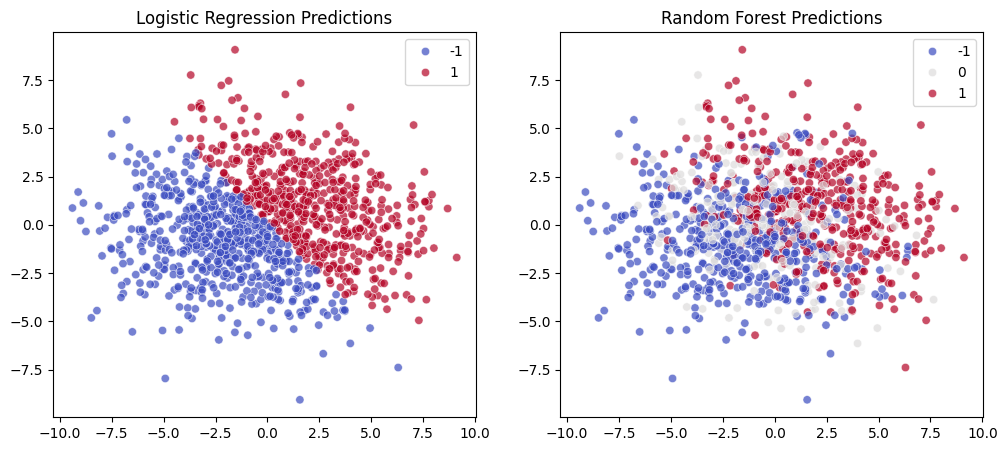

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
df = data_model_corr6
# 1. Wczytanie danych (zakładam, że masz już DataFrame 'df')
X = df.drop(columns=["result"])  # Cechy
y = df["result"]  # Wynik meczu (-1, 0, 1)

# 2. Normalizacja danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Redukcja wymiarowości PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 5. Trenowanie modeli
# - Regresja logistyczna
log_reg_poly = LogisticRegression(multi_class="multinomial", solver="newton-cg")
log_reg_poly.fit(X_train, y_train)
y_pred_logreg_poly = log_reg_poly.predict(X_test)
# - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 6. Ocena modeli
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg_poly))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_logreg_poly))

print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf))

# 7. Wizualizacja decyzji modelu
plt.figure(figsize=(12, 5))

# Logistic Regression decision boundary
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_logreg_poly, palette="coolwarm", alpha=0.7)
plt.title("Logistic Regression Predictions")

# Random Forest decision boundary
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred_rf, palette="coolwarm", alpha=0.7)
plt.title("Random Forest Predictions")

plt.show()


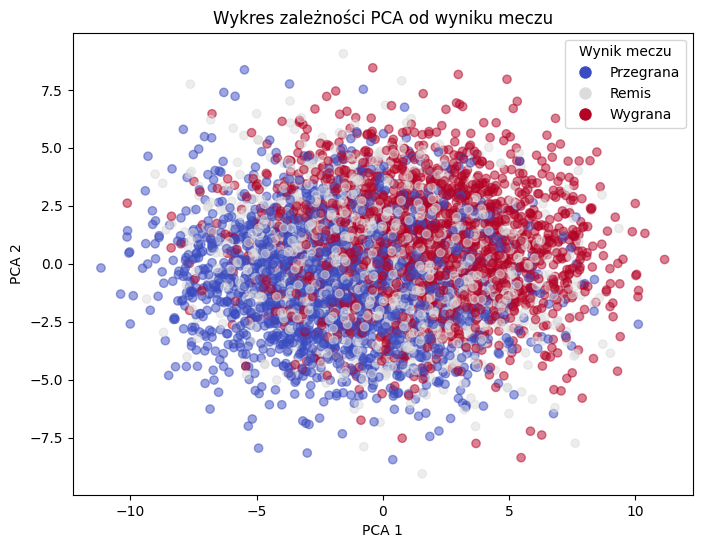

In [150]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cmap = cm.get_cmap("coolwarm")
norm = mcolors.Normalize(vmin=-1, vmax=1)
colors = [cmap(norm(value)) for value in y]

# Tworzenie wykresu
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5)

# Tworzenie legendy
legend_labels = {-1: "Przegrana", 0: "Remis", 1: "Wygrana"}
legend_colors = [cmap(norm(value)) for value in legend_labels.keys()]
legend_patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=legend_colors[i], markersize=10, label=label) 
                  for i, label in enumerate(legend_labels.values())]

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Wykres zależności PCA od wyniku meczu")
plt.legend(handles=legend_patches, title="Wynik meczu")
plt.show()

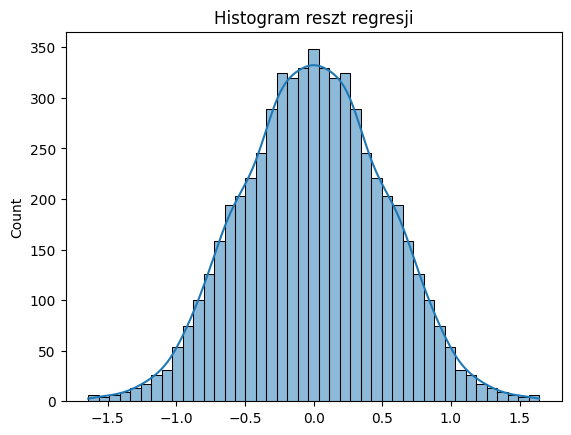

In [151]:
X = data_model_corr6_scaled.drop(columns=['result'])
y = data_model_corr6_scaled['result']

X = sm.add_constant(X)  # Dodajemy stałą do modelu
model = sm.OLS(y, X).fit()
residuals = model.resid

sns.histplot(residuals, kde=True)
plt.title("Histogram reszt regresji")
plt.show()

In [152]:
data_model_pos_group2 = data_model_pos_group.groupby('grouped_positions')[['goals', 'assist', 'PAxG', 'npxg', 'shots_on_target', 'xGA', 'fwp+', 'carries_into_pen', 'shots', 'xT+', 'prog_pass', 'prog_carries']].sum().reset_index()

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [154]:
cor_df = data_model_corr3[['result', 'PAxG_diff', 'npxg_diff', 'shots_on_target_diff', 'xGA_diff', 'fwp+_diff', 'xT+_diff', 'carries_into_pen_diff', 'shots_diff', 'prog_carries_diff', 'prog_pass_diff']]

In [155]:
cor_df_scaled = cor_df.copy()
cor_df_scaled.iloc[:, 1:] = scaler.fit_transform(cor_df.iloc[:, 1:])
cor_df_scaled

,result,PAxG_diff,npxg_diff,shots_on_target_diff,xGA_diff,fwp+_diff,xT+_diff,carries_into_pen_diff,shots_diff,prog_carries_diff,prog_pass_diff
0,1,2.033516,0.615588,1.638607,0.869404,-0.099535,0.528372,1.534640,0.752528,0.079272,1.277354
1,-1,-2.033516,-0.615588,-1.638607,-0.869404,0.099535,-0.528372,-1.534640,-0.752528,-0.079272,-1.277354
2,1,-0.484094,-0.072119,-0.273101,0.028174,0.153266,0.467218,-0.219234,-0.627106,0.237816,0.666445
3,-1,0.484094,0.072119,0.273101,-0.028174,-0.153266,-0.467218,0.219234,0.627106,-0.237816,-0.666445
4,0,-0.268122,-0.528963,-0.546202,-0.505868,-0.637726,-0.630296,-0.657703,-0.752528,-0.396360,-1.110742
...,...,...,...,...,...,...,...,...,...,...,...
5843,1,0.526376,0.792208,0.546202,1.694560,0.779364,0.861866,0.876937,0.877949,0.475632,0.999668
5844,0,0.628665,1.447139,0.546202,1.149651,-0.126576,1.047775,-0.219234,0.627106,0.554904,0.388760
5845,0,-0.628665,-1.447139,-0.546202,-1.149651,0.126576,-1.047775,0.219234,-0.627106,-0.554904,-0.388760
5846,0,-0.562056,-0.305065,-0.546202,0.001168,0.093721,-0.543864,0.876937,-1.003370,-0.000000,-0.721983


In [156]:
X = cor_df_scaled.drop(columns='result')
y = cor_df['result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [157]:
def train_and_evaluate(model, model_name):
    print(f"\n🔹 Model: {model_name}")
    
    # Trening modelu
    model.fit(X_train, y_train)
    
    # Predykcja na zbiorze testowym
    y_pred = model.predict(X_test)
    
    # 📌 Wyświetlenie wyników
    print(classification_report(y_test, y_pred))
    
    # 📌 Accuracy & F1-score
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"🎯 Accuracy: {acc:.4f}, F1-score: {f1:.4f}")

    # 📌 Ważność cech (jeśli model ją obsługuje)
    if hasattr(model, "coef_"):  # Dla regresji logistycznej
        feature_importance = np.mean(np.abs(model.coef_), axis=0)
        plot_feature_importance(feature_importance, model_name)
    
    if hasattr(model, "feature_importances_"):  # Dla Random Forest, XGBoost, LightGBM
        plot_feature_importance(model.feature_importances_, model_name)


In [158]:
def plot_feature_importance(importances, model_name):
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title(f'📊 Feature Importance - {model_name}')
    plt.show()



🔹 Model: Random Forest
              precision    recall  f1-score   support

          -1       0.81      0.85      0.83       431
           0       0.63      0.59      0.61       308
           1       0.84      0.83      0.83       431

    accuracy                           0.78      1170
   macro avg       0.76      0.76      0.76      1170
weighted avg       0.77      0.78      0.77      1170

🎯 Accuracy: 0.7752, F1-score: 0.7736


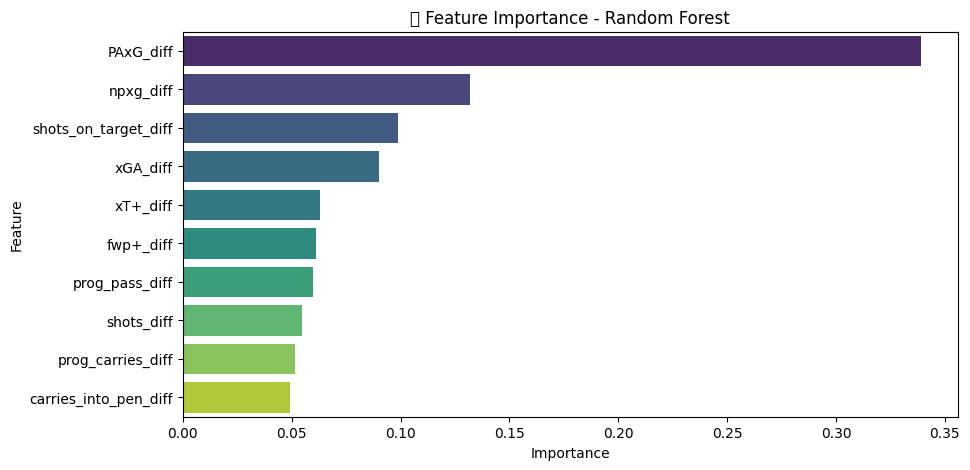


🔹 Model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000608 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1576
[LightGBM] [Info] Number of data points in the train set: 4678, number of used features: 10
[LightGBM] [Info] Start training from score -0.998804
[LightGBM] [Info] Start training from score -1.334232
[LightGBM] [Info] Start training from score -0.998804
              precision    recall  f1-score   support

          -1       0.82      0.82      0.82       431
           0       0.60      0.61      0.61       308
           1       0.83      0.83      0.83       431

    accuracy                           0.77      1170
   macro avg       0.75      0.75      0.75      1170
weighted avg       0.77      0.77      0.77      1170

🎯 Accuracy: 0.7692, F1-score: 0.7695


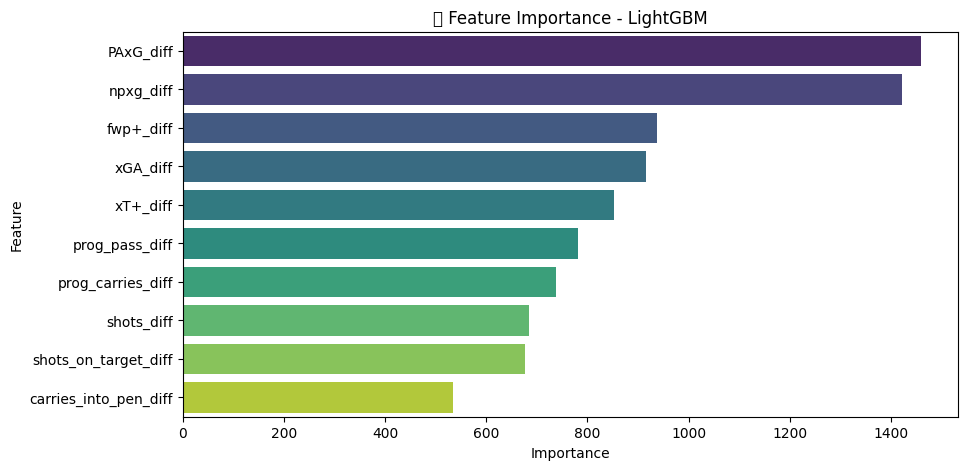

In [159]:


# 🔹 Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
train_and_evaluate(rf, "Random Forest")


# 🔹 LightGBM
lgbm = LGBMClassifier(objective='multiclass', num_class=3)
train_and_evaluate(lgbm, "LightGBM")




In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score

# Wczytanie danych (przyjmuję, że masz już znormalizowane statystyki i wynik meczu w df)
X = cor_df_scaled.drop(columns='result')
y = cor_df['result']

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tworzenie modeli
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lgbm = LGBMClassifier(objective='multiclass', num_class=3, random_state=42)

# Trenowanie modeli
rf.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

# Predykcja
y_pred_rf = rf.predict(X_test)
y_pred_lgbm = lgbm.predict(X_test)

# Obliczanie metryk
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted')

## Ważności cech
feature_importances_rf = rf.feature_importances_ / rf.feature_importances_.sum()
feature_importances_lgbm = lgbm.feature_importances_ / lgbm.feature_importances_.sum()

# Średnia ważności cech
feature_importance_avg = (feature_importances_rf + feature_importances_lgbm) / 2

# Sortowanie cech
sorted_idx_rf = np.argsort(feature_importances_rf)[::-1]
sorted_idx_lgbm = np.argsort(feature_importances_lgbm)[::-1]
sorted_idx_avg = np.argsort(feature_importance_avg)[::-1]



X.columns = ["PAxG", "NPxG", "Shot Of Target", "xGA", "Forward Passes", "xT", "Carries IPA", "Shots", "Prog Carries", "Prog Pass"]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1575
[LightGBM] [Info] Number of data points in the train set: 4678, number of used features: 10
[LightGBM] [Info] Start training from score -0.999384
[LightGBM] [Info] Start training from score -1.310966
[LightGBM] [Info] Start training from score -1.015188


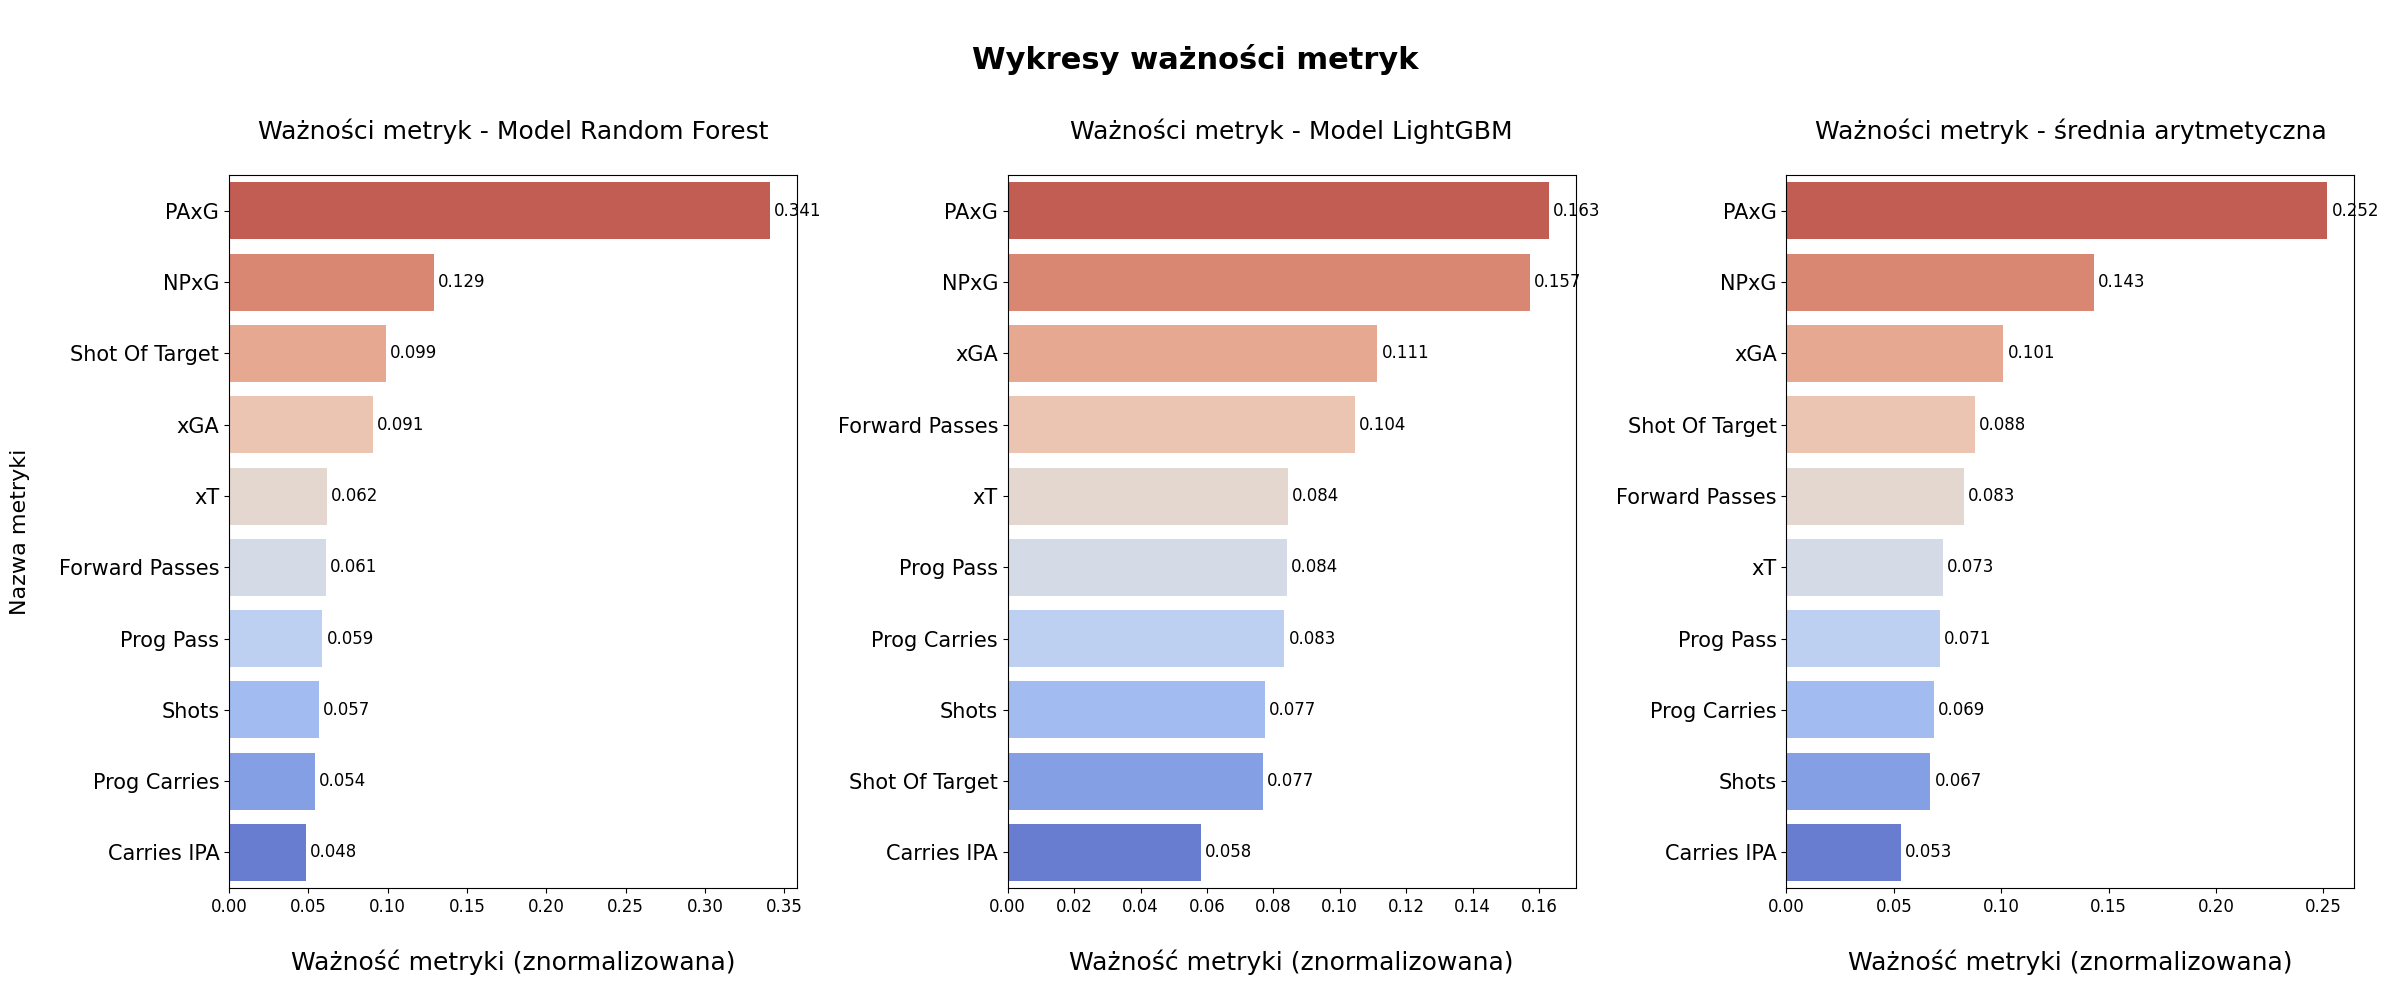

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tworzenie wykresu
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Funkcja do dodania wartości nad słupkami
def add_value_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=12, padding=3)

sns.barplot(x=feature_importances_rf[sorted_idx_rf], y=X.columns[sorted_idx_rf], ax=axes[0], palette="coolwarm_r")
axes[0].set_title("Ważności metryk - Model Random Forest\n", fontsize=18)
axes[0].set_xlabel("\nWażność metryki (znormalizowana)", fontsize=18)
axes[0].set_ylabel("Nazwa metryki\n", fontsize=16)
axes[0].tick_params(axis='y', labelsize=15)
axes[0].tick_params(axis='x', labelsize=12)
add_value_labels(axes[0])  # Dodanie wartości nad słupkami

sns.barplot(x=feature_importances_lgbm[sorted_idx_lgbm], y=X.columns[sorted_idx_lgbm], ax=axes[1], palette="coolwarm_r")
axes[1].set_title("Ważności metryk - Model LightGBM\n", fontsize=18)
axes[1].set_xlabel("\nWażność metryki (znormalizowana)", fontsize=18)
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', labelsize=15)
axes[1].tick_params(axis='x', labelsize=12)
add_value_labels(axes[1])  # Dodanie wartości

sns.barplot(x=feature_importance_avg[sorted_idx_avg], y=X.columns[sorted_idx_avg], ax=axes[2], palette="coolwarm_r")
axes[2].set_title("Ważności metryk - średnia arytmetyczna\n", fontsize=18)
axes[2].set_xlabel("\nWażność metryki (znormalizowana)", fontsize=18)
axes[2].set_ylabel("")
axes[2].tick_params(axis='y', labelsize=15)
axes[2].tick_params(axis='x', labelsize=12)
add_value_labels(axes[2])  # Dodanie wartości

plt.suptitle("\nWykresy ważności metryk\n", fontsize=22, weight='bold')
plt.tight_layout()
plt.show()



🔹 Trenuję model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1576
[LightGBM] [Info] Number of data points in the train set: 4678, number of used features: 10
[LightGBM] [Info] Start training from score -0.998804
[LightGBM] [Info] Start training from score -1.334232
[LightGBM] [Info] Start training from score -0.998804
🎯 Accuracy: 0.7692 | 🎯 F1-score: 0.7695
              precision    recall  f1-score   support

          -1       0.82      0.82      0.82       431
           0       0.60      0.61      0.61       308
           1       0.83      0.83      0.83       431

    accuracy                           0.77      1170
   macro avg       0.75      0.75      0.75      1170
weighted avg       0.77      0.77      0.77      1170


🔹 Trenuję model: CatBoost
🎯 Accuracy: 0.7573 | 🎯 F1-score: 0.7566
              precision    recall  

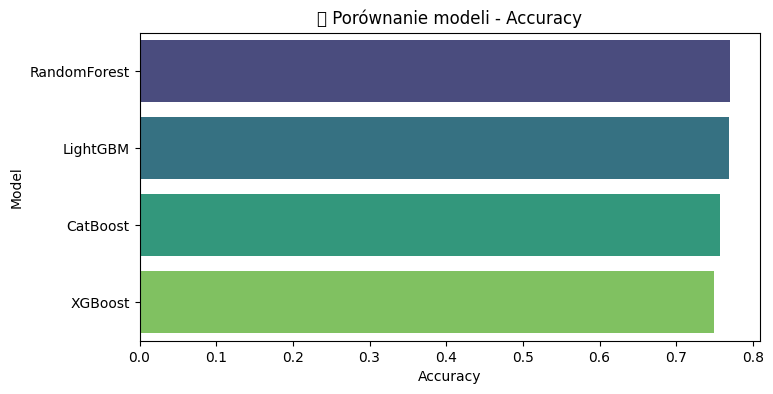

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  # Zmiana z HistGradientBoosting na XGBClassifier

# 📌 Podział na X (cechy) i y (wynik meczu)
X = cor_df_scaled.drop(columns=['result'])
y = cor_df_scaled['result']

# 📌 Stratified Split (zachowanie proporcji klas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 📌 Mapowanie klas: (-1 → 0, 0 → 1, 1 → 2) dla modeli, które tego wymagają
y_train_map = y_train.map({-1: 0, 0: 1, 1: 2})
y_test_map = y_test.map({-1: 0, 0: 1, 1: 2})

# 📌 Lista modeli do testów
models = {
    "LightGBM": LGBMClassifier(objective='multiclass', num_class=3, random_state=42),
    "CatBoost": CatBoostClassifier(loss_function='MultiClass', verbose=0, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', random_state=42)  # Dodanie XGBoost
}

# 📌 Testowanie modeli
results = []
for name, model in models.items():
    print(f"\n🔹 Trenuję model: {name}")
    
    if name in ["LightGBM", "CatBoost", "XGBoost"]:  # Modele obsługujące multiclass natywnie
        model.fit(X_train, y_train_map)
        y_pred = model.predict(X_test)
    else:  # Inne modele działają bez mapowania klas
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Odwrócenie mapowania
    if name in ["LightGBM", "CatBoost", "XGBoost"]:
        y_pred = pd.Series(y_pred.ravel()).map({0: -1, 1: 0, 2: 1})

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append((name, acc, f1))
    print(f"🎯 Accuracy: {round(acc, 4)} | 🎯 F1-score: {round(f1, 4)}")
    print(classification_report(y_test, y_pred))

# 📌 Wizualizacja wyników
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score"]).sort_values(by="Accuracy", ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("📊 Porównanie modeli - Accuracy")
plt.show()


In [164]:
percent_df = data_model_pos_group2.copy()
stat_cols = data_model_pos_group2.columns[1:]  # Pomijamy 'grouped_positions'
for col in stat_cols:
    total = data_model_pos_group2[col].sum()
    percent_df[col] = (data_model_pos_group2[col] / total) * 100

percent_df


data_model_pos_group_rating = data_model_pos_group[['player', 'team', 'match_id', 'position', 'goals', 'assist', 'PAxG', 'npxg', 'shots_on_target', 'xGA', 'fwp+', 'carries_into_pen', 'shots', 'xT+', 'prog_pass', 'prog_carries']]

colum = data_model_pos_group_rating.columns[4:]

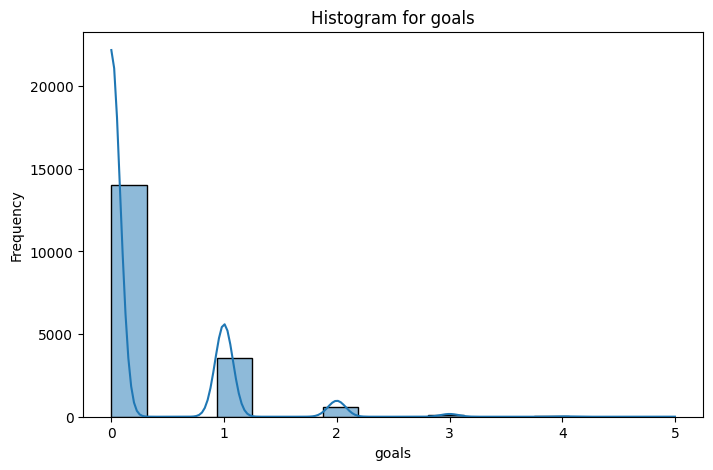

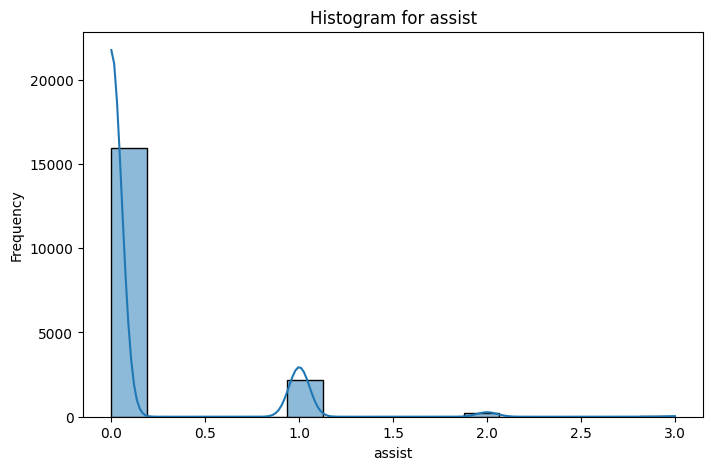

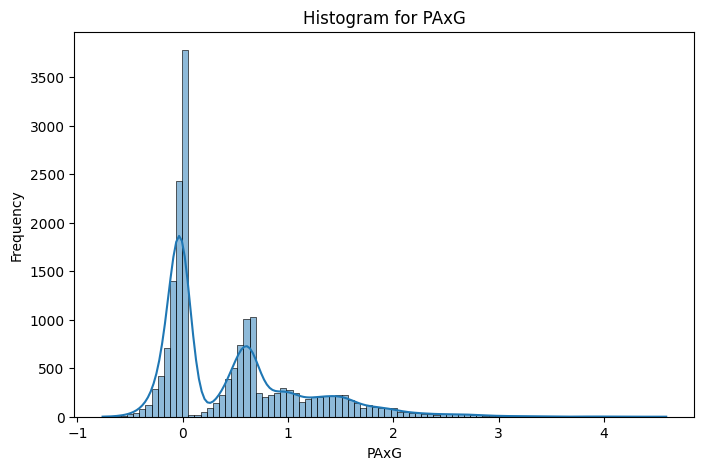

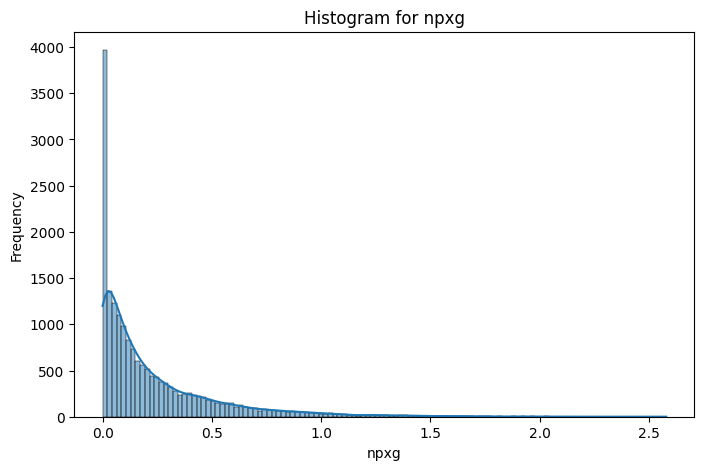

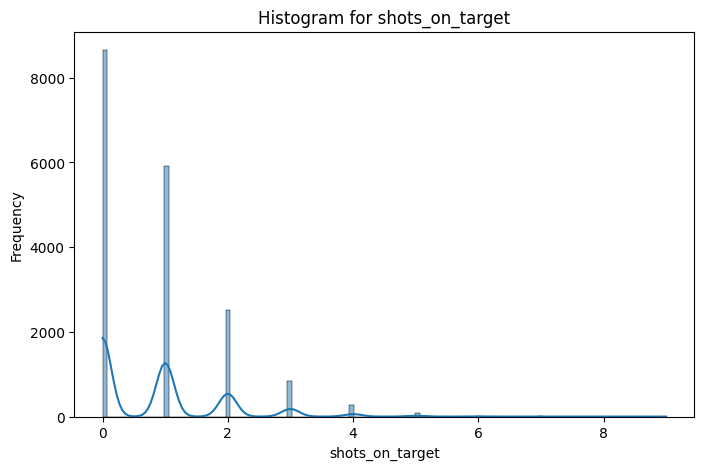

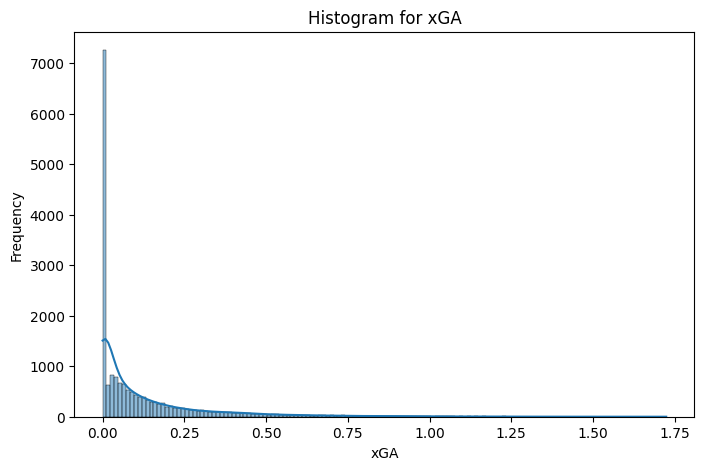

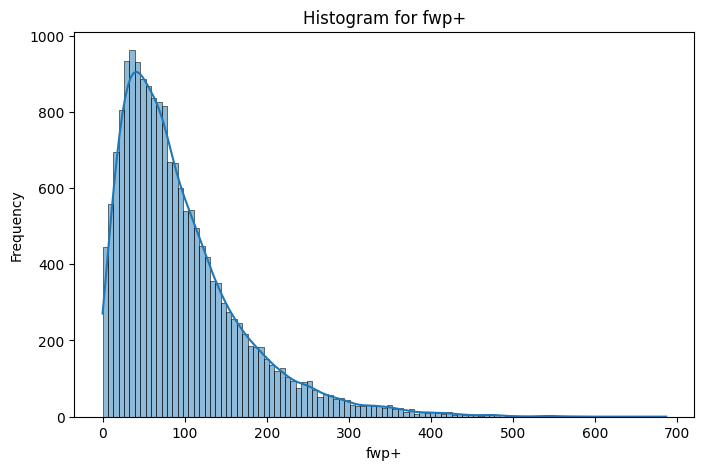

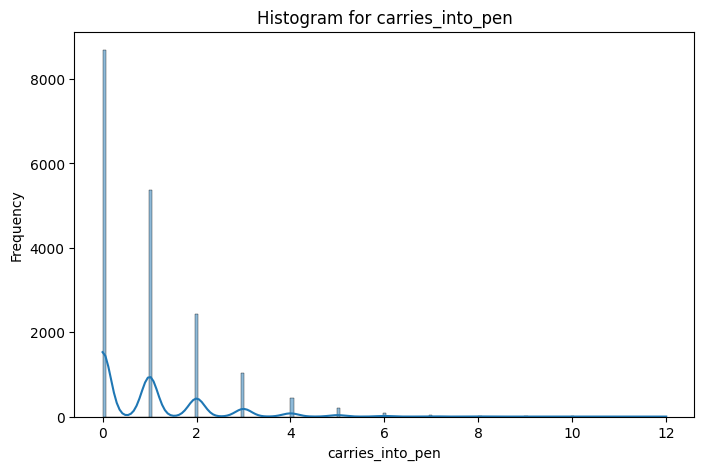

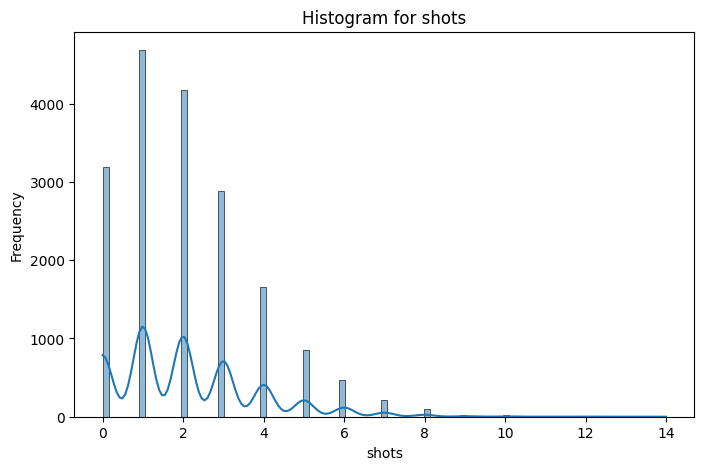

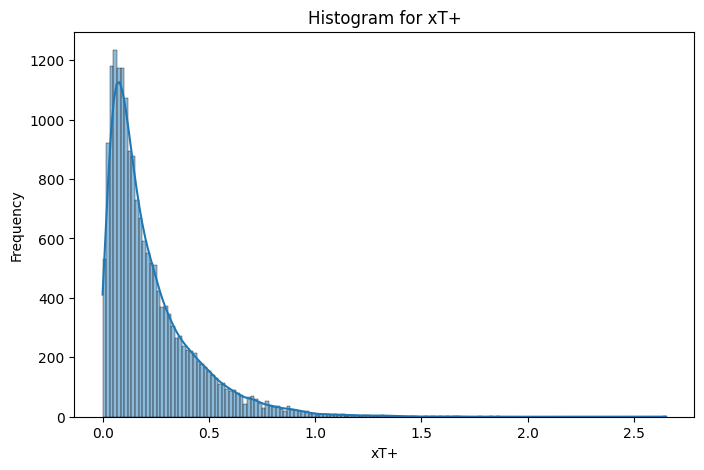

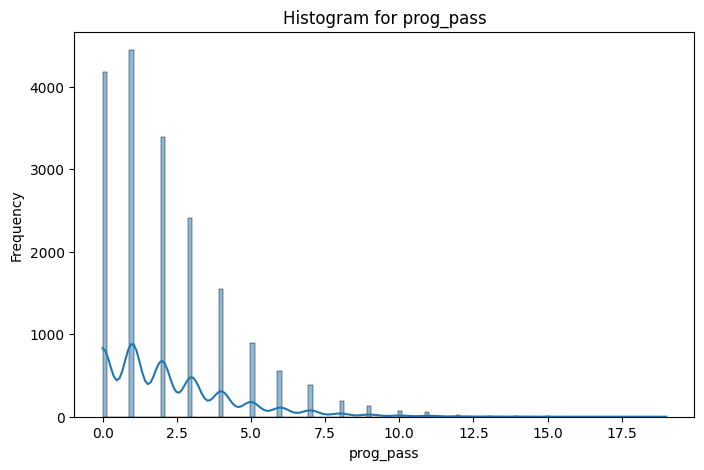

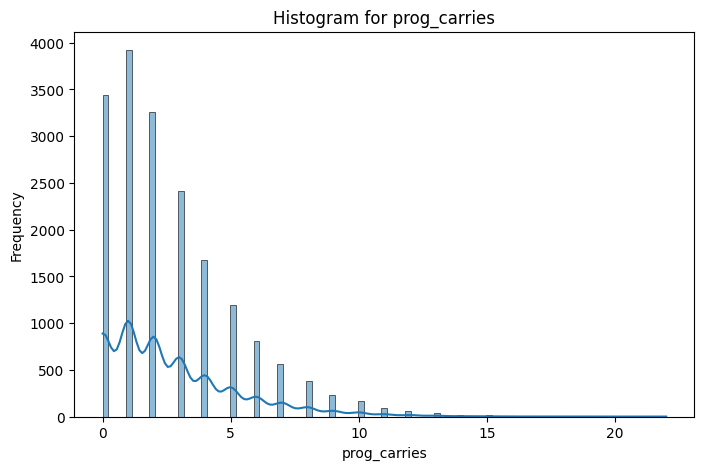

In [165]:
for c in colum:
    plt.figure(figsize=(8, 5))  # Rozmiar wykresu
    sns.histplot(data_model_pos_group_rating[c], kde=True)  # Histogram z krzywą KDE
    plt.title(f'Histogram for {c}')  # Tytuł
    plt.xlabel(c)  # Etykieta osi X
    plt.ylabel('Frequency')  # Etykieta osi Y
    plt.show()  # Wyświetlenie wykresu

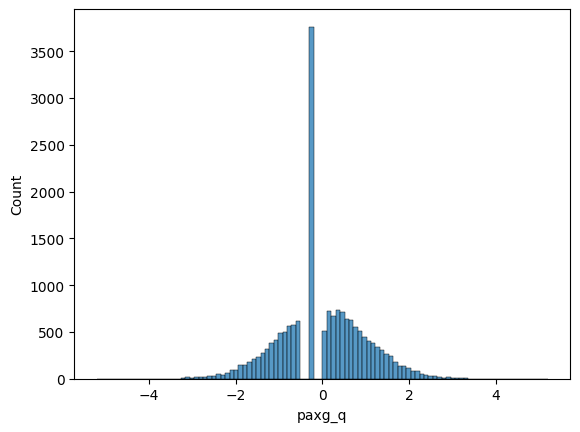

In [166]:
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', random_state=42)
rating = data_model_pos_group_rating.copy()
rating[['paxg_q']] = qt.fit_transform(data_model_pos_group_rating[['PAxG']])
sns.histplot(rating['paxg_q'])

rating[['prog_carries_q']] = qt.fit_transform(data_model_pos_group_rating[['prog_carries']])
rating['xga_l'] = np.log1p(data_model_pos_group_rating['xGA'] + 0.01)

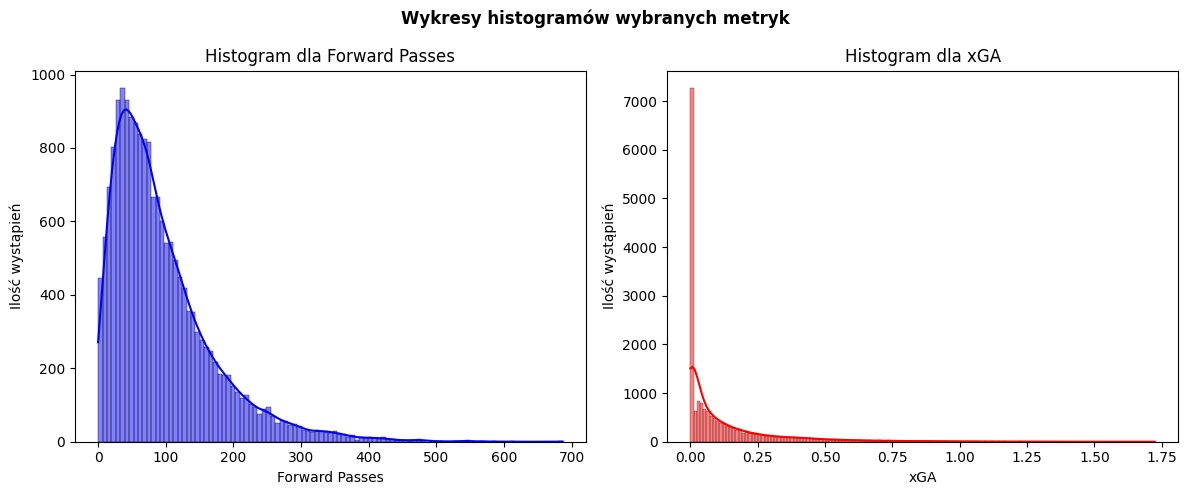

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Tworzymy 2 wykresy obok siebie

# Pierwszy histogram
sns.histplot(data_model_pos_group_rating['fwp+'], kde=True, color='blue', ax=axes[0])
axes[0].set_title('Histogram dla Forward Passes')
axes[0].set_xlabel('Forward Passes')
axes[0].set_ylabel('Ilość wystąpień')

# Drugi histogram
sns.histplot(data_model_pos_group_rating['xGA'], kde=True, color='red', ax=axes[1])
axes[1].set_title('Histogram dla xGA')
axes[1].set_xlabel('xGA')
axes[1].set_ylabel('Ilość wystąpień')
plt.suptitle("Wykresy histogramów wybranych metryk", weight="bold")
plt.tight_layout()  # Dopasowanie układu
plt.show()

<Axes: xlabel='rating_weights', ylabel='Count'>

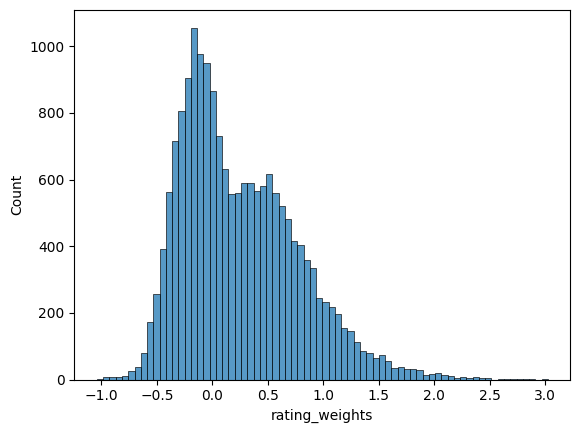

In [168]:
rating['prog_pass_l'] = np.log1p(rating['prog_pass'] + 0.01)
rating['prog_carries_l'] = np.log1p(rating['prog_carries'] + 0.01)
rating[['xT+_q']] = qt.fit_transform(rating[['xT+']])
rating[['fwp+_q']] = qt.fit_transform(rating[['fwp+']])
rating['shots_s'] = scaler.fit_transform(rating[['shots']])
rating['prog_carries_s'] = scaler.fit_transform(rating[['prog_carries']])
rating['prog_pass_s'] = scaler.fit_transform(rating[['prog_pass']])
rating['carries_into_pen_l'] = np.log1p(rating['carries_into_pen'] + 0.01)
rating['npxg_s'] = scaler.fit_transform(rating[['npxg']])
rating['goals_l'] = np.log1p(rating['goals'] + 0.01)
rating['assist_l'] = np.log1p(rating['assist'] + 0.01)
rating['shots_on_target_l'] = np.log1p(rating['shots_on_target'] + 0.01)
rating['paxg_c'] = rating['paxg_q'] - rating['paxg_q'].median()
rating['paxg_2'] = scaler.fit_transform(rating[['PAxG']])
rating['rating_weights'] = 0.28*rating['paxg_c'] + 0.18*rating['npxg_s'] + 0.1*rating['shots_on_target_l'] + 0.08*rating['xga_l'] + 0.07 * rating['fwp+_q'] + 0.05*rating['carries_into_pen_l'] + 0.07*rating['shots_s'] + 0.07*rating['xT+_q'] + 0.05*rating['prog_pass_l'] + 0.05*rating['prog_carries_l']
sns.histplot(rating['rating_weights'])

<Axes: xlabel='score_scaled', ylabel='Count'>

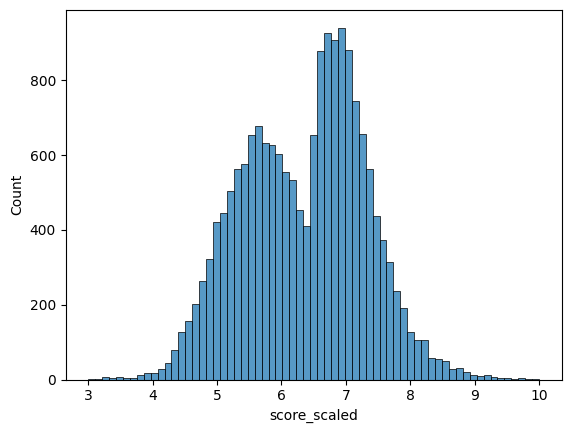

In [169]:
min_val = rating['rating_weights'].min()
max_val = rating['rating_weights'].max()
median_val = rating['rating_weights'].median()

def scale_score(x):
    if x <= median_val:
        # Skala dla wartości poniżej mediany (3 do 6.5)
        return 3 + 3.5 * (x - min_val) / (median_val - min_val)
    else:
        # Skala dla wartości powyżej mediany (6.5 do 10)
        return 6.5 + 3.5 * (x - median_val) / (max_val - median_val)

# Zastosowanie funkcji
rating['score_scaled'] = rating['rating_weights'].apply(scale_score)

sns.histplot(rating['score_scaled'])


In [170]:
strikers = ['Secondary Striker', 'Center Forward', 'Right Center Forward', 'Left Center Forward']

In [171]:
data_model_pos_group_rating_strikers = data_model_pos_group_rating[data_model_pos_group_rating['position'].isin(strikers)]

In [172]:
rating_strikers = data_model_pos_group_rating_strikers

<Axes: xlabel='paxg_q', ylabel='Count'>

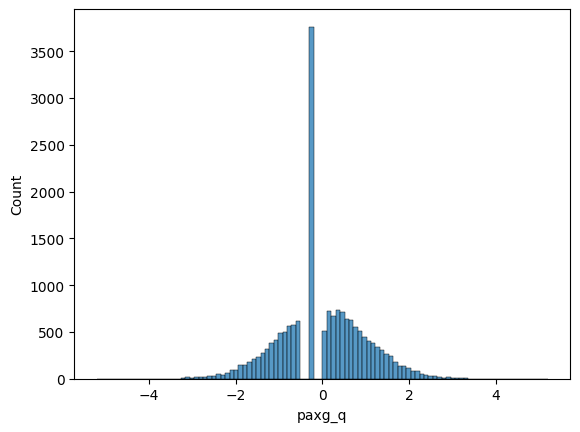

In [173]:
rating_strikers[['paxg_q']] = qt.fit_transform(rating_strikers[['PAxG']]+0.01)
sns.histplot(rating['paxg_q'])

<Axes: xlabel='xga_l', ylabel='Count'>

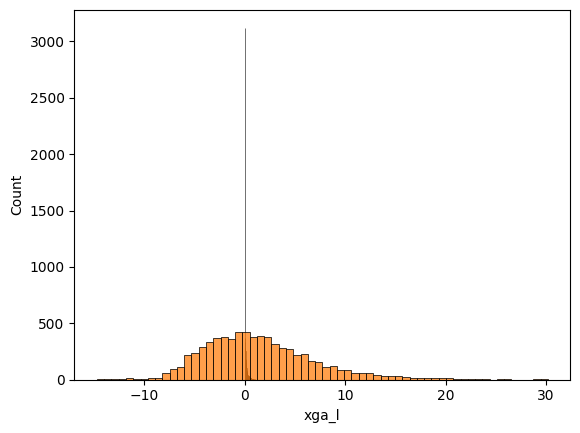

In [174]:
rating_strikers['xga_l'] = np.log1p(rating_strikers['xGA'] + 0.01)
sns.histplot(rating_strikers['xga_l'])
rating_strikers['prog_pass_l'] = np.log1p(rating_strikers['prog_pass'] + 0.01)
rating_strikers['prog_carries_l'] = np.log1p(rating_strikers['prog_carries'] + 0.01)
rating_strikers[['xT+_q']] = qt.fit_transform(rating_strikers[['xT+']])
rating_strikers[['fwp+_q']] = qt.fit_transform(rating_strikers[['fwp+']])
rating_strikers['shots_s'] = scaler.fit_transform(rating_strikers[['shots']])
rating_strikers['carries_into_pen_l'] = np.log1p(rating_strikers['carries_into_pen'] + 0.01)
rating_strikers['npxg_s'] = scaler.fit_transform(rating_strikers[['npxg']])
rating_strikers['goals_l'] = np.log1p(rating_strikers['goals'] + 0.01)
rating_strikers['assist_l'] = np.log1p(rating_strikers['assist'] + 0.01)
rating_strikers['shots_on_target_l'] = np.log1p(rating_strikers['shots_on_target'] + 0.01)
rating_strikers['prog_carries_s'] = scaler.fit_transform(rating_strikers[['prog_carries']])
rating_strikers['prog_pass_s'] = scaler.fit_transform(rating_strikers[['prog_pass']])
rating_strikers['prog_pass_l'] = np.log1p(rating_strikers['prog_pass'] + 0.01)
rating_strikers['prog_carries_l'] = np.log1p(rating_strikers['prog_carries'] + 0.01)
rating_strikers['shots_l'] = np.log1p(rating_strikers['shots'] + 0.01)
rating_strikers['npxg_l'] = np.log1p(rating_strikers['npxg'] + 0.01)
rating_strikers['rating_all'] = rating_strikers['xT+_q'] + rating_strikers['fwp+_q'] + rating_strikers['paxg_q'] + rating_strikers['prog_carries_s'] + rating_strikers['prog_pass_s'] + rating_strikers['shots_s'] + rating_strikers['xga_l'] + rating_strikers['carries_into_pen_l'] + rating_strikers['npxg_s'] + rating_strikers['goals_l'] + rating_strikers['assist_l'] + rating_strikers['shots_on_target_l']
sns.histplot(rating_strikers['rating_all'])

<Axes: xlabel='npxg_l', ylabel='Count'>

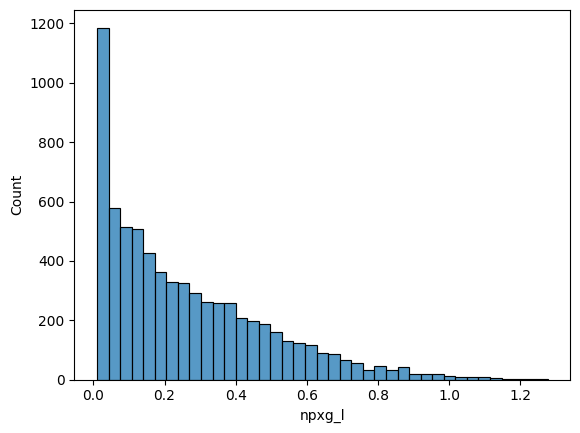

In [175]:
sns.histplot(rating_strikers['npxg_l'])

In [176]:
rating_strikers['rating_all_weights'] = 0.07*rating_strikers["xT+_q"] + 0.07*rating_strikers['fwp+_q'] + 0.28*rating_strikers['paxg_q'] + 0.05*rating_strikers['prog_carries_l'] + 0.05*rating_strikers['prog_pass_l'] + 0.07*rating_strikers['shots_s'] + 0.08*rating_strikers['xga_l'] + 0.05*rating_strikers['carries_into_pen_l'] + 0.18*rating_strikers['npxg_l']  + 0.1*rating_strikers['shots_on_target_l']

<Axes: xlabel='rating_all_weights', ylabel='Count'>

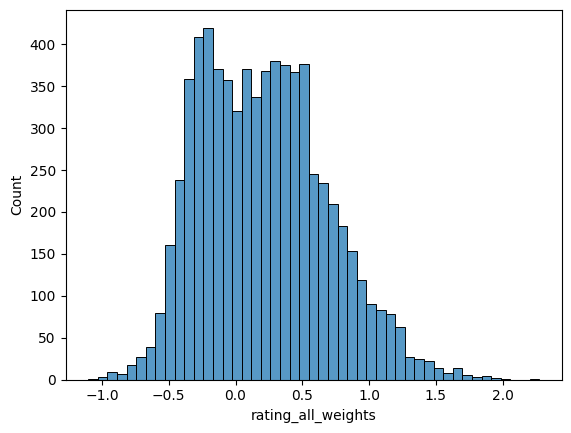

In [177]:
sns.histplot(rating_strikers['rating_all_weights'])

<Axes: xlabel='score_scaled', ylabel='Count'>

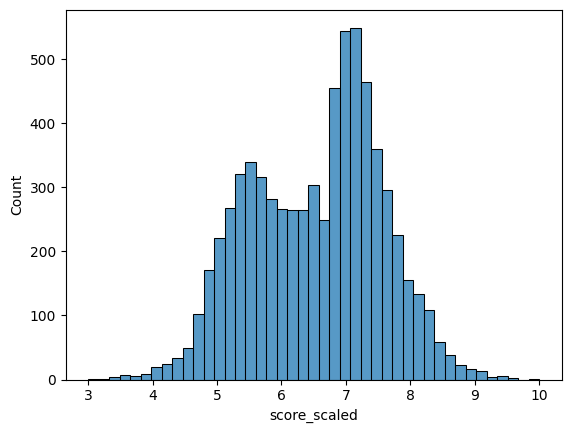

In [178]:
min_val = rating_strikers['rating_all_weights'].min()
max_val = rating_strikers['rating_all_weights'].max()
median_val = rating_strikers['rating_all_weights'].mean()

def scale_score(x):
    if x <= median_val:
        # Skala dla wartości poniżej mediany (3 do 6.5)
        return 3 + 3.8 * (x - min_val) / (median_val - min_val)
    else:
        # Skala dla wartości powyżej mediany (6.5 do 10)
        return 6.8 + 3.2 * (x - median_val) / (max_val - median_val)

# Zastosowanie funkcji
rating_strikers['score_scaled'] = rating_strikers['rating_all_weights'].apply(scale_score)

sns.histplot(rating_strikers['score_scaled'])

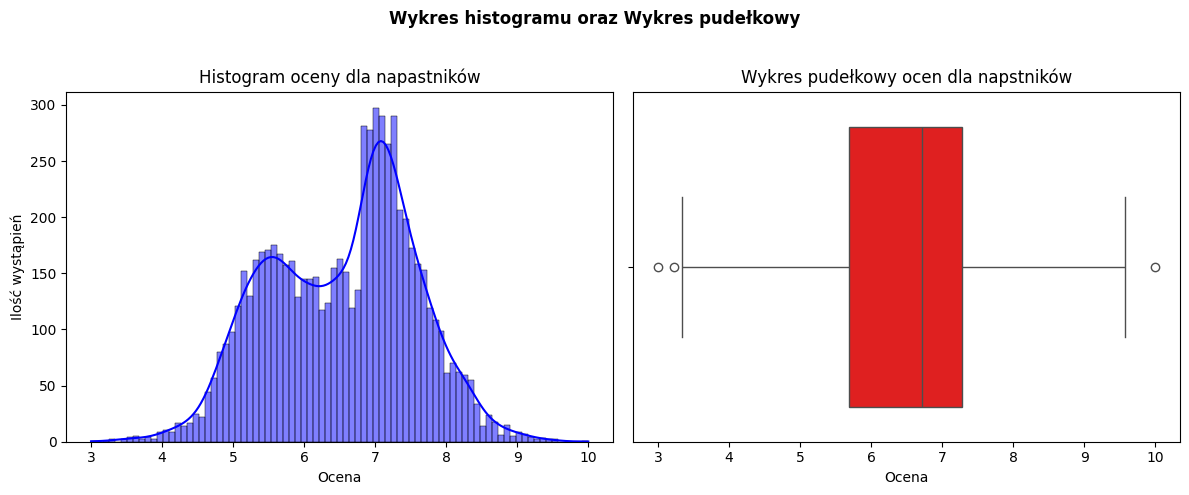

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Dwa wykresy obok siebie

# Histogram
sns.histplot(rating_strikers['score_scaled'], bins=83, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Histogram oceny dla napastników')
axes[0].set_xlabel('Ocena')
axes[0].set_ylabel('Ilość wystąpień')

# Boxplot
sns.boxplot(x=rating_strikers['score_scaled'], ax=axes[1], color='red')
axes[1].set_title('Wykres pudełkowy ocen dla napstników')
axes[1].set_xlabel('Ocena')

plt.suptitle("Wykres histogramu oraz Wykres pudełkowy\n", weight="bold")
plt.tight_layout()  # Dopasowanie układu
plt.show()


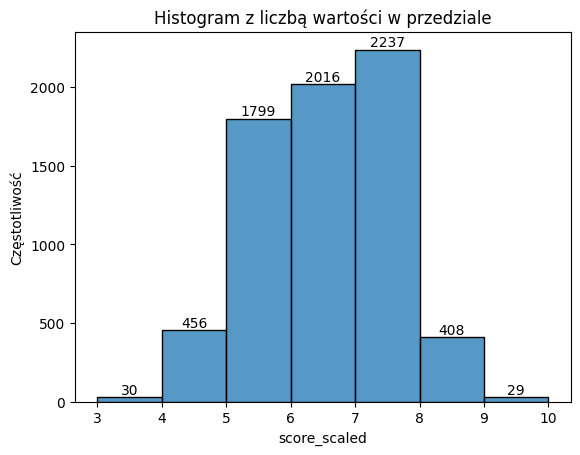

In [180]:
ax = sns.histplot(rating_strikers['score_scaled'], bins=7)

# Dodanie liczby do każdego słupka histogramu
for patch in ax.patches:
    # Wysokość słupka
    height = patch.get_height()
    # Pozycja słupka na osi X
    x_position = patch.get_x() + patch.get_width() / 2
    # Dodanie liczby do słupka
    ax.text(x_position, height, f'{int(height)}', ha='center', va='bottom')

# Dodatkowe opcje wykresu
plt.title('Histogram z liczbą wartości w przedziale')
plt.xlabel('score_scaled')
plt.ylabel('Częstotliwość')

# Pokaż wykres
plt.show()

<Axes: ylabel='score_scaled'>

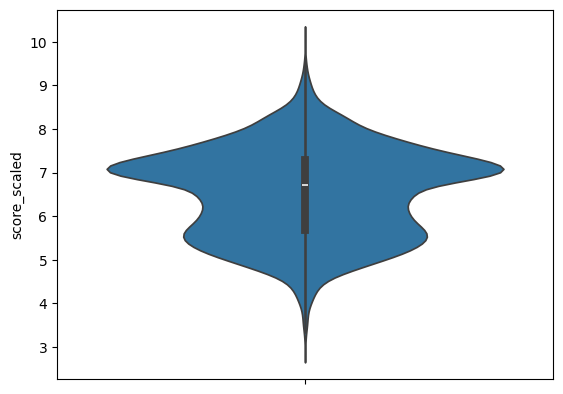

In [181]:
sns.violinplot(rating_strikers['score_scaled'])

<Axes: xlabel='rating_all', ylabel='Count'>

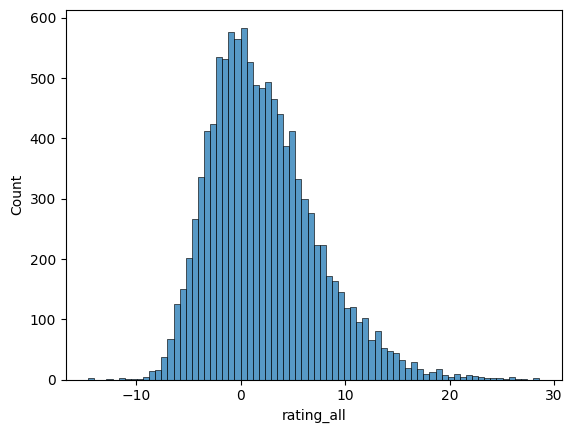

In [182]:
data_model_pos_group_rating_mid = data_model_pos_group_rating[data_model_pos_group_rating['position'].isin(pos_wings)]
rating_mid = data_model_pos_group_rating_mid
mid = rating[rating.columns[:-3]]
mid = mid[mid['position'].isin(pos_wings)]
mid['rating_all'] = mid['xT+_q'] + mid['fwp+_q'] + mid['paxg_q'] + mid['prog_carries_s'] + mid['prog_pass_s'] + mid['shots_s'] + mid['xga_l'] + mid['carries_into_pen_l'] + mid['npxg_s'] + mid['goals_l'] + mid['assist_l'] + mid['shots_on_target_l'] + mid['goals_l'] + mid['assist_l']
sns.histplot(mid['rating_all'])

<Axes: xlabel='rating_all_weights', ylabel='Count'>

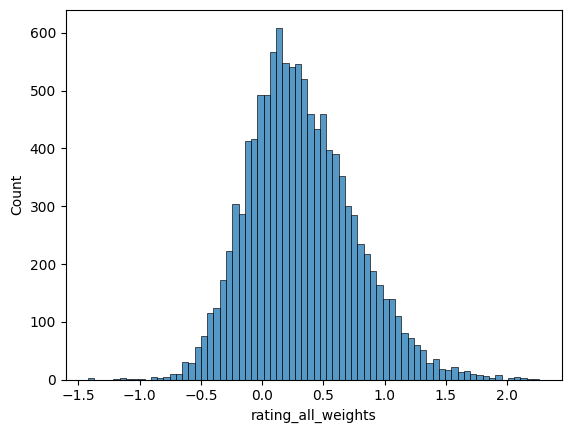

In [183]:
mid['rating_all_weights'] = 0.11*mid['xT+_q'] + 0.13*mid['fwp+_q'] + 0.2*mid['paxg_q'] + 0.09*mid['prog_carries_l'] + 0.1*mid['prog_pass_l'] + 0.05*mid['shots_s'] + 0.12*mid['xga_l'] + 0.05*mid['carries_into_pen_l'] + 0.09*mid['npxg_s'] + 0.06*mid['shots_on_target_l']
sns.histplot(mid['rating_all_weights'])

<Axes: xlabel='score_scaled', ylabel='Count'>

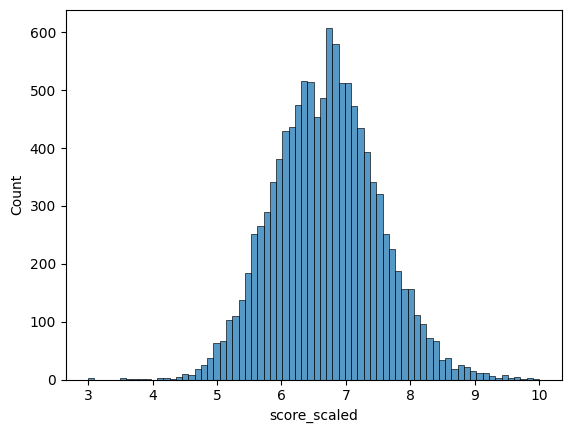

In [184]:
min_val = mid['rating_all_weights'].min()
max_val = mid['rating_all_weights'].max()
median_val = mid['rating_all_weights'].median()

def scale_score(x):
    if x <= median_val:
        # Skala dla wartości poniżej mediany (3 do 6.5)
        return 3 + 3.7 * (x - min_val) / (median_val - min_val)
    else:
        # Skala dla wartości powyżej mediany (6.5 do 10)
        return 6.7 + 3.3 * (x - median_val) / (max_val - median_val)

# Zastosowanie funkcji
mid['score_scaled'] = mid['rating_all_weights'].apply(scale_score)

sns.histplot(mid['score_scaled'])


In [185]:
from scipy.stats import shapiro

stat, p_value = shapiro(rating_strikers['score_scaled'])
print('Statystyka testu:', stat)
print('Wartość p:', p_value)

Statystyka testu: 0.9855879545211792
Wartość p: 4.6298832010124277e-26


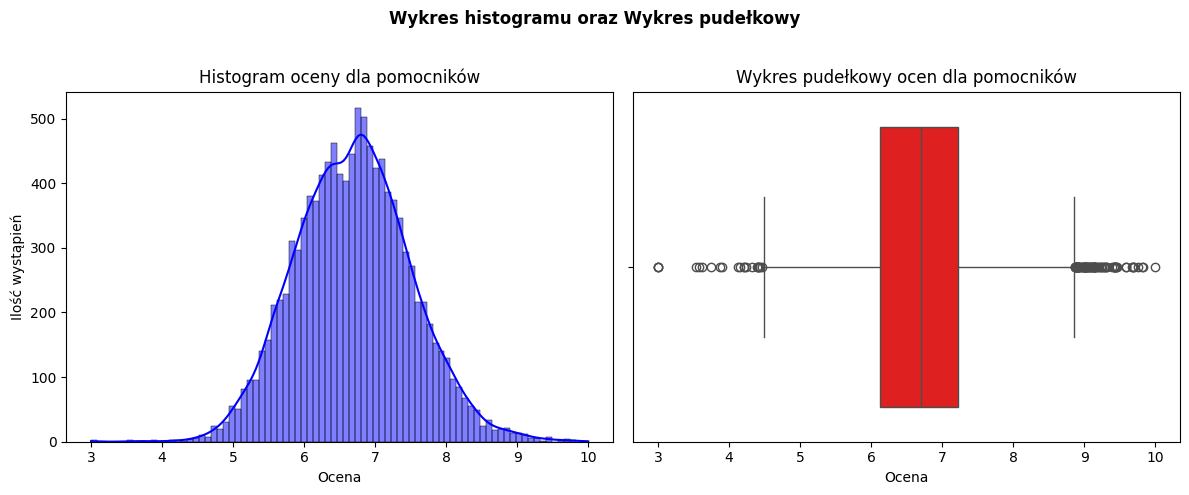

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Dwa wykresy obok siebie

# Histogram
sns.histplot(mid['score_scaled'], bins=83, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Histogram oceny dla pomocników')
axes[0].set_xlabel('Ocena')
axes[0].set_ylabel('Ilość wystąpień')

# Boxplot
sns.boxplot(x=mid['score_scaled'], ax=axes[1], color='red')
axes[1].set_title('Wykres pudełkowy ocen dla pomocników')
axes[1].set_xlabel('Ocena')

plt.suptitle("Wykres histogramu oraz Wykres pudełkowy\n", weight="bold")
plt.tight_layout()  # Dopasowanie układu
plt.show()


In [187]:
result = pd.concat(
    [rating_strikers, 
     mid],
    ignore_index=True  # Resetuje indeks w nowym DataFrame
)

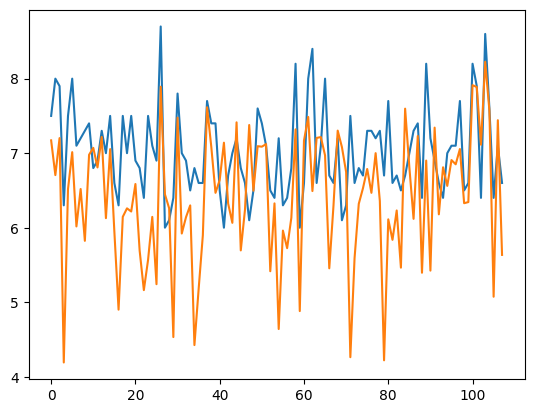

In [188]:
euro24_match_list = list(sb.matches(competition_id=55, season_id=282)['match_id'])
euro24_ratings = result[result['match_id'].isin(euro24_match_list)].sort_values(by=['match_id', 'team'])
euro24_ratings[['match_id','player', 'team', 'position']].to_excel('ratings.xlsx')
sofa_rating = pd.read_excel('ratings_my.xlsx')
sofa = sofa_rating[['match_id', 'player', 'team', 'rating']].merge(result[['match_id', 'player', 'team', 'score_scaled']], on=['match_id', 'player', 'team']).sort_values(by='rating')
df = sofa.sort_values(by='match_id')
df["new_column"] = range(len(df))
plt.plot(df['new_column'], df['rating'])
plt.plot(df['new_column'], df['score_scaled'])

<Axes: xlabel='score_scaled', ylabel='Count'>

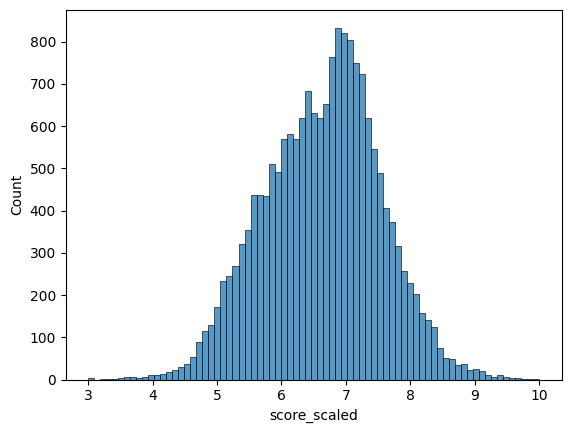

In [189]:
sns.histplot(result['score_scaled'])

In [190]:
euro24_ratings_mean = euro24_ratings[['player', 'score_scaled']].groupby('player')['score_scaled'].mean().reset_index().sort_values(by='score_scaled')
euro24_players = euro24_ratings.groupby('player', as_index=False)[euro24_ratings.columns[4:-20]].mean()
players_radar = ['Kevin De Bruyne', 'Kylian Mbappé Lottin', 'Lamine Yamal Nasraoui Ebana']
radar_plot = euro24_players[euro24_players['player'].isin(players_radar)]
params = list(radar_plot.columns[1:])
radar_plot.reset_index(drop=True, inplace=True)
ranges = []
a_values = []
b_values = []
c_values = []

for x in params:
    a = min(radar_plot[params][x])
    a = a - (a*.25)
    
    b = max(radar_plot[params][x])
    b = b + (b*.25)
    
    ranges.append((a,b))
    
for x in range(len(radar_plot['player'])):
    if radar_plot['player'][x] == 'Kevin De Bruyne':
        a_values = radar_plot.iloc[x].values.tolist()
    if radar_plot['player'][x] == 'Kylian Mbappé Lottin':
        b_values = radar_plot.iloc[x].values.tolist()
    if radar_plot['player'][x] == 'Lamine Yamal Nasraoui Ebana':
        c_values = radar_plot.iloc[x].values.tolist()
        
a_values = a_values[1:]
b_values = b_values[1:]
#c_values = c_values[1:]

values = [a_values,b_values]

In [191]:
title = dict(
    title_name='Kevin De Bruyne',
    title_color = 'red',
    subtitle_name = 'Belgium',
    subtitle_color = 'red',
    title_name_2='Kylian Mbappé Lottin',
    title_color_2 = 'blue',
    subtitle_name_2 = 'France',
    subtitle_color_2 = 'blue',
    title_fontsize = 18,
    subtitle_fontsize=15
)
endnote = '@inz\nTop rated player in EURO 2024'

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

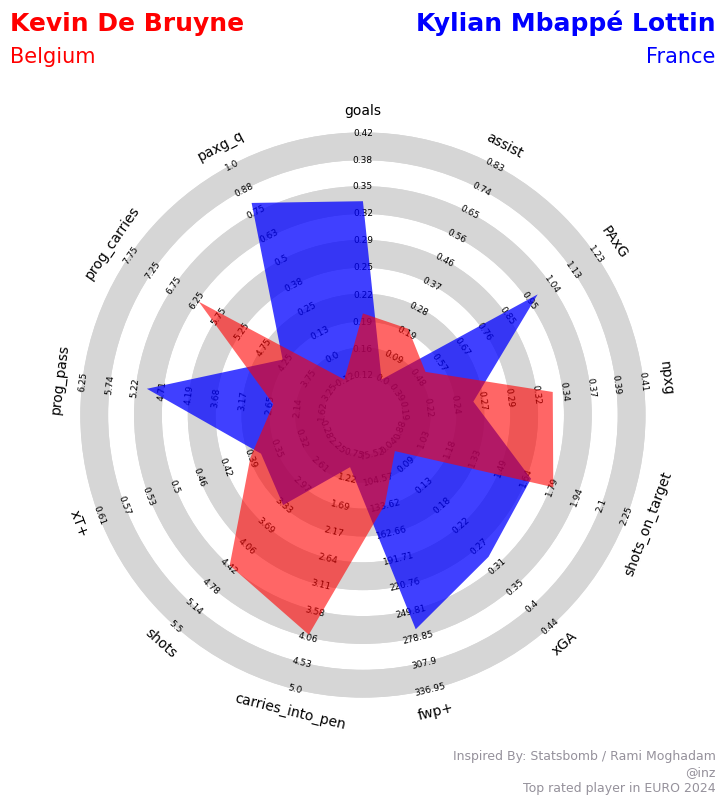

In [192]:
from soccerplots.radar_chart import Radar
plt.rcParams["font.family"] = "serif"  # Or any other available font
radar = Radar()

fig,ax = radar.plot_radar(ranges=ranges,params=params,values=values,
                         radar_color=['blue', 'red'],
                         alphas=[.75,.6],title=title,endnote=endnote,
                         compare=True)

In [193]:
comparison = sofa.merge(euro24_ratings[euro24_ratings.columns[:-20]], on=['match_id', 'player', 'team'])
comparison2 = comparison[['rating', 'goals', 'assist', 'PAxG', 'npxg', 'shots_on_target', 'xGA', 'fwp+', 'carries_into_pen', 'shots', 'xT+', 'prog_pass', 'prog_carries']]

In [194]:
X = comparison2.drop(columns='rating')
y = comparison2['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

RMSE: 0.5402977293711648
R^2: 0.162626254963551


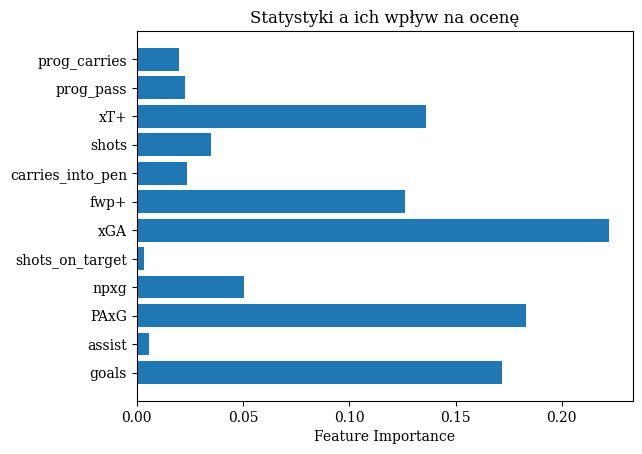

In [195]:
y_pred = model.predict(X_test)
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R^2:", r2_score(y_test, y_pred))
importance = model.feature_importances_

# Wizualizacja
features = X.columns
plt.barh(features, importance)
plt.xlabel('Feature Importance')
plt.title('Statystyki a ich wpływ na ocenę')
plt.show()

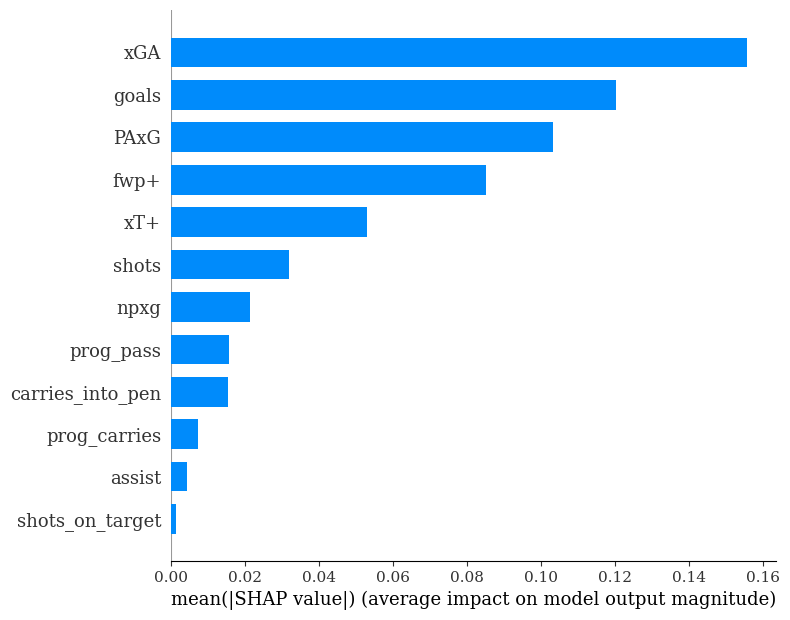

In [196]:
import shap

# SHAP dla wyjaśnienia modelu
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Wizualizacja
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [197]:
sofa_24 = pd.read_excel('ratingsv2.xlsx')
sofa24 = sofa_24[sofa_24.columns[1:]]

In [198]:
ratings_df = euro24_ratings[list(euro24_ratings.columns[:16]) + ['score_scaled']].merge(sofa24, on=['match_id', 'team', 'player', 'position'])
ratings_df = ratings_df.sort_values(by='rating').iloc[1:]
ratings_df['score_scaled'] = ratings_df['score_scaled'].round(1)

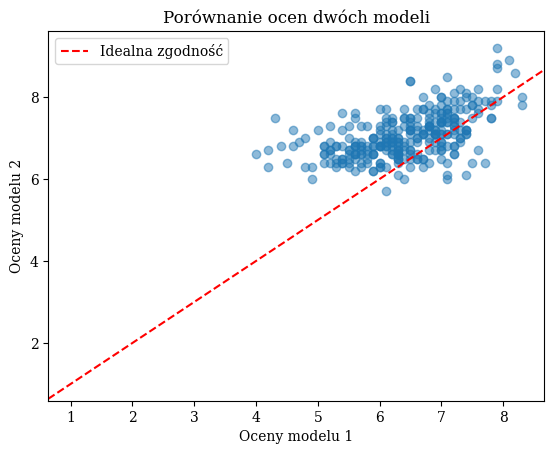

In [199]:
plt.scatter(ratings_df['score_scaled'], ratings_df['rating'], alpha=0.5)
plt.xlabel("Oceny modelu 1")
plt.ylabel("Oceny modelu 2")
plt.title("Porównanie ocen dwóch modeli")
plt.axline((1,1), slope=1, color='red', linestyle='--', label="Idealna zgodność")
plt.legend()
plt.show()

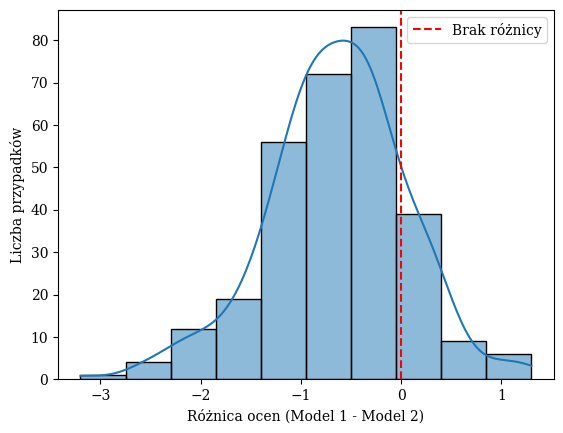

In [200]:
diff = np.array(ratings_df['score_scaled']) - np.array(ratings_df['rating'])

sns.histplot(diff, bins=10, kde=True)
plt.axvline(0, color='red', linestyle='--', label="Brak różnicy")
plt.xlabel("Różnica ocen (Model 1 - Model 2)")
plt.ylabel("Liczba przypadków")
plt.legend()
plt.show()

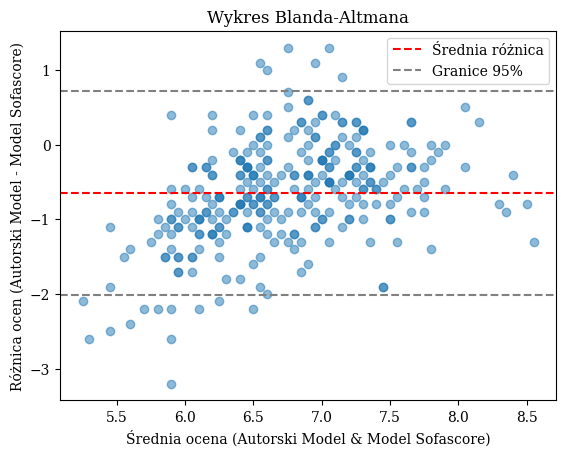

In [201]:


mean_scores = (np.array(ratings_df['score_scaled']) + np.array(ratings_df['rating'])) / 2
diff_scores = np.array(ratings_df['score_scaled']) - np.array(ratings_df['rating'])

fig, ax = plt.subplots()
ax.scatter(mean_scores, diff_scores, alpha=0.5)
ax.axhline(np.mean(diff_scores), color='red', linestyle='--', label="Średnia różnica")
ax.axhline(np.mean(diff_scores) + 1.96*np.std(diff_scores), color='gray', linestyle='--', label="Granice 95%")
ax.axhline(np.mean(diff_scores) - 1.96*np.std(diff_scores), color='gray', linestyle='--')
ax.set_xlabel("Średnia ocena (Autorski Model & Model Sofascore)")
ax.set_ylabel("Różnica ocen (Autorski Model - Model Sofascore)")
ax.legend()
plt.title("Wykres Blanda-Altmana")
plt.show()

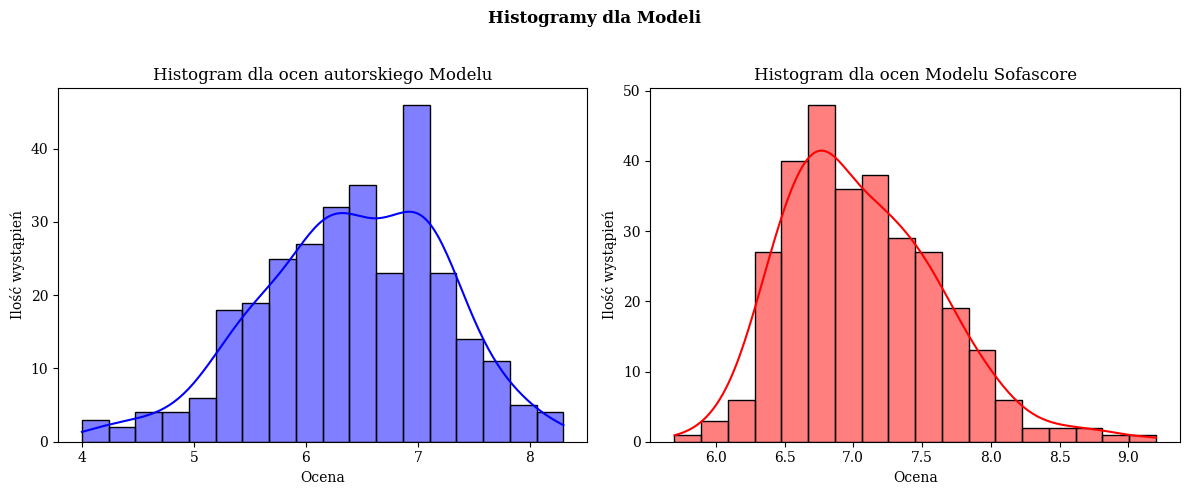

In [202]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Tworzymy 2 wykresy obok siebie

# Pierwszy histogram
sns.histplot(ratings_df['score_scaled'], bins=18, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Histogram dla ocen autorskiego Modelu')
axes[0].set_xlabel('Ocena')
axes[0].set_ylabel('Ilość wystąpień')

# Drugi histogram
sns.histplot(ratings_df['rating'], bins=18, kde=True, color='red', ax=axes[1])
axes[1].set_title('Histogram dla ocen Modelu Sofascore')
axes[1].set_xlabel('Ocena')
axes[1].set_ylabel('Ilość wystąpień')

plt.suptitle("Histogramy dla Modeli\n", weight="bold")
plt.tight_layout()  # Dopasowanie układu
plt.show()


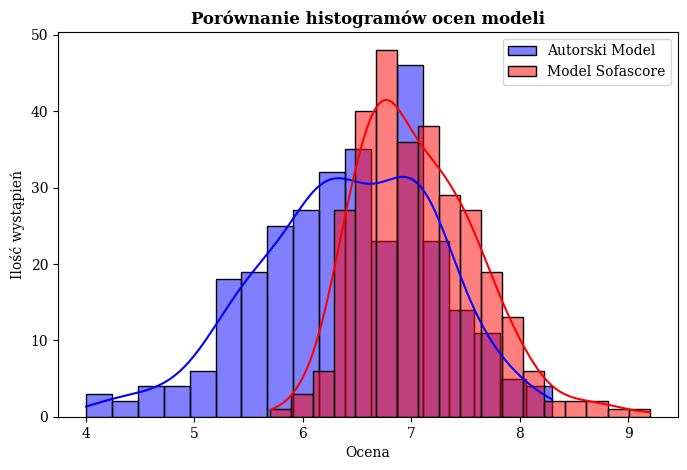

In [203]:
plt.figure(figsize=(8, 5))  # Rozmiar wykresu

# Histogram dla obu modeli na jednym wykresie
sns.histplot(ratings_df['score_scaled'], bins=18, kde=True, color='blue', alpha=0.5, label='Autorski Model')
sns.histplot(ratings_df['rating'], bins=18, kde=True, color='red', alpha=0.5, label='Model Sofascore')

plt.title("Porównanie histogramów ocen modeli", weight="bold")
plt.xlabel("Ocena")
plt.ylabel("Ilość wystąpień")
plt.legend()  # Dodanie legendy
plt.show()

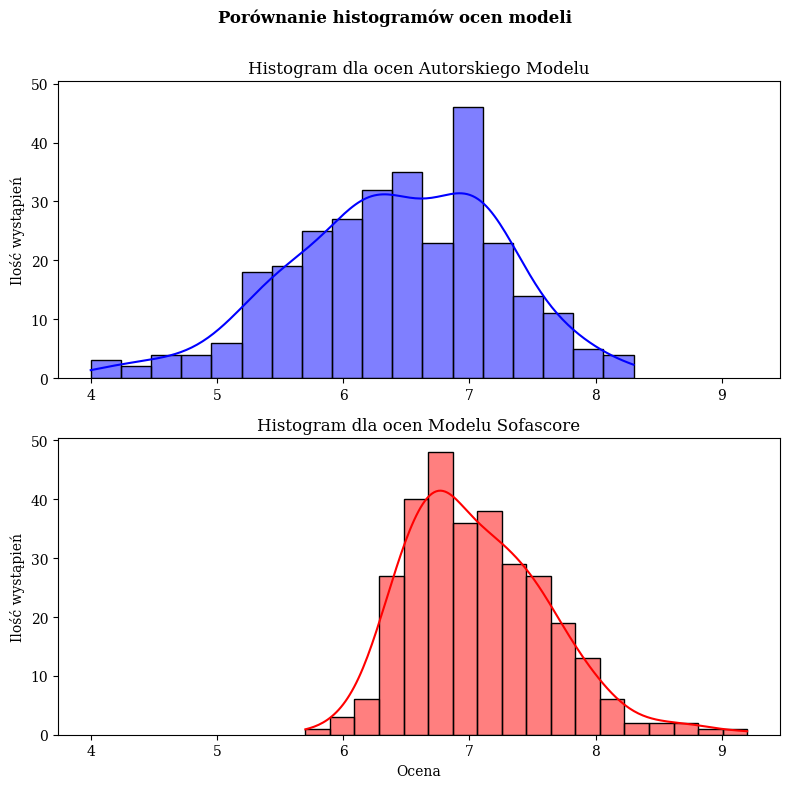

In [204]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, sharey=True)  # Zachowujemy wspólną skalę

# Pierwszy histogram (Autorski Model)
sns.histplot(ratings_df['score_scaled'], bins=18, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Histogram dla ocen Autorskiego Modelu')
axes[0].set_ylabel('Ilość wystąpień')
axes[0].tick_params(axis='x', labelbottom=True)  # Włączenie liczb na osi X

# Drugi histogram (Model Sofascore)
sns.histplot(ratings_df['rating'], bins=18, kde=True, color='red', ax=axes[1])
axes[1].set_title('Histogram dla ocen Modelu Sofascore')
axes[1].set_xlabel('Ocena')
axes[1].set_ylabel('Ilość wystąpień')

# Główna nazwa wykresu
plt.suptitle("Porównanie histogramów ocen modeli\n", weight="bold")

plt.tight_layout()  # Dopasowanie układu
plt.show()